In [2]:
import numpy as np #I use numpy for most things. It plays well with other things, and I find it avoids data type conflicts well
from numpy import genfromtxt #This will help read in a data file as a numpy array
from scipy.optimize import curve_fit #This will help us do nonlinear least squares fitting.

import matplotlib.pyplot as plt #This allows you to plot things using the Matplotlib library. 

## Tungsten (W)

Reduced Chi Squared = 2.877
a1 = 1920.396 ± 59.964
mu1 = 137.486 ± 0.169
sigma1 = 5.061 ± 0.180
a2 = 981.474 ± 45.727
mu2 = 159.604 ± 0.216
sigma2 = 4.263 ± 0.288
y0 = 164.643 ± 38.785


Text(0.5, 0.01, 'Caption: Intensity vs energy for a tungsten target, using x-rays from a Cu anode.')

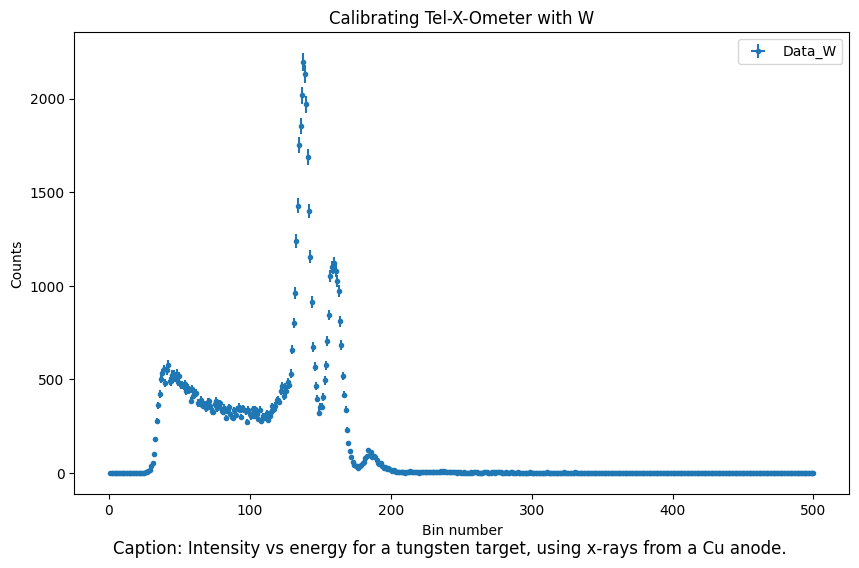

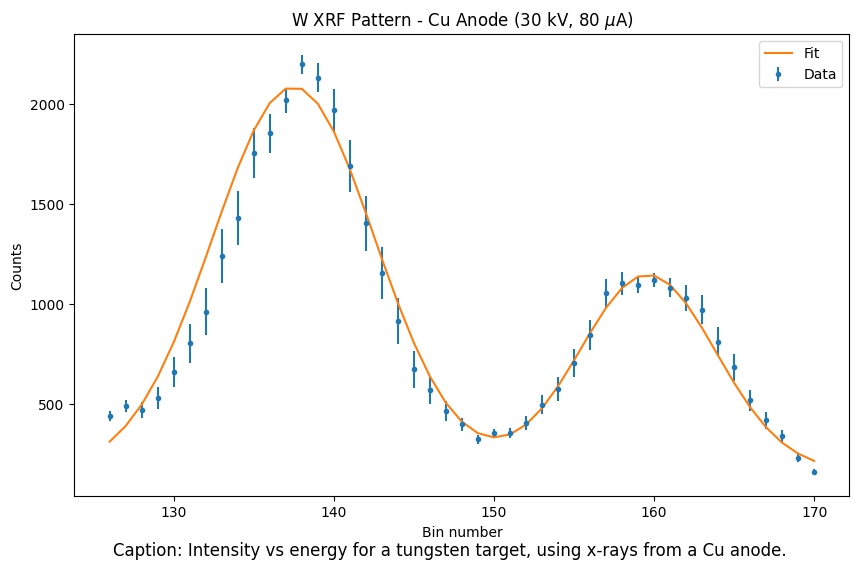

In [35]:
#KEY REMOVE FOR STUDENTS
#Import "xray_calibration_data.txt"
data = genfromtxt("xray_calibration_data.txt", delimiter='	', skip_header=0)
Bin = data[:, 0]
I_W = data[:, 1]
Bin_error = np.array([0.5 for x in Bin])
I_W_error = np.sqrt(I_W)

Bin_range = Bin[125:170]
Bin_error_range = Bin_error[125:170]
I_W_range = I_W[125:170]
I_W_error_range = I_W_error[125:170]

#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(Bin, I_W, xerr = Bin_error, yerr = I_W_error, fmt='.', label="Data_W")
plt.legend()
plt.xlabel('Bin number')
plt.ylabel('Counts')
plt.title('Calibrating Tel-X-Ometer with W')
plt.figtext(0.5, 0.01, "Caption: Intensity vs energy for a tungsten target, using x-rays from a Cu anode.", wrap=True, horizontalalignment='center', fontsize=12)

#Make a Model Function
def Gaussian_W(x, a1, mu1, sigma1, a2, mu2, sigma2, y0):
    g = a1 * np.exp(-0.5 * (x - mu1)**2 / sigma1**2) + a2 * np.exp(-0.5 * (x - mu2)**2 / sigma2**2) + y0
    return g

#Preliminarily Fit the Data
guess_a1 = 2250
guess_mu1 = 130
guess_sigma1 = 5
guess_a2 = 1100
guess_mu2 = 160
guess_sigma2 = 5
guess_y0 = 1



guess=np.array([guess_a1, guess_mu1, guess_sigma1, guess_a2, guess_mu2, guess_sigma2, guess_y0])

uw_fits,uw_covs=curve_fit(Gaussian_W, Bin_range, I_W_range, p0=guess)
uw_sig=np.sqrt(np.diag(uw_covs))

#Calculate dg/dx
a1, mu1, sigma1, a2, mu2, sigma2, y0 = uw_fits
dg_dx = -((Bin_range - mu1) / sigma1**2) * a1 * np.exp(-0.5 * (Bin_range - mu1)**2 / sigma1**2) - ((Bin_range - mu2) / sigma2**2) * a2 * np.exp(-0.5 * (Bin_range - mu2)**2 / sigma2**2) 

#Calculate total error
sigmas= np.sqrt(I_W_error_range**2 + (dg_dx * Bin_error_range)**2)

#Perform weighted fit
fits, covs=curve_fit(Gaussian_W, Bin_range, I_W_range, p0=guess, sigma=sigmas)
stds=np.sqrt(np.diag(covs))


#Calculate reduced chi squared
Red_chi_sq_W= 1.0/(Bin_range.size-7.0) * np.sum((I_W_range - Gaussian_W(Bin_range, *fits))**2/sigmas**2)
print(f'Reduced Chi Squared = {Red_chi_sq_W:.3f}')
print(f"a1 = {fits[0]:.3f} ± {stds[0]:.3f}")
print(f"mu1 = {fits[1]:.3f} ± {stds[1]:.3f}")
print(f"sigma1 = {fits[2]:.3f} ± {stds[2]:.3f}")
print(f"a2 = {fits[3]:.3f} ± {stds[3]:.3f}")
print(f"mu2 = {fits[4]:.3f} ± {stds[4]:.3f}")
print(f"sigma2 = {fits[5]:.3f} ± {stds[5]:.3f}")
print(f"y0 = {fits[6]:.3f} ± {stds[6]:.3f}")
                 

#Plot the fit with the data!
fit_I_W = Gaussian_W(Bin_range, *fits)
fig1=plt.figure(1, figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(Bin_range, I_W_range, yerr=sigmas, fmt='.', label="Data")
plt.plot(Bin_range, fit_I_W, '-', label="Fit")
plt.legend()
plt.xlabel('Bin number')
plt.ylabel('Counts')
plt.title(r'W XRF Pattern - Cu Anode (30 kV, 80 $\mu$A)')
plt.figtext(0.5, 0.01, "Caption: Intensity vs energy for a tungsten target, using x-rays from a Cu anode.", wrap=True, horizontalalignment='center', fontsize=12)





## Molybdenum (Mo)

Reduced Chi Squared = 1.281
a1 = 233.717 ± 7.673
mu1 = 285.614 ± 0.160
sigma1 = 4.880 ± 0.119
a2 = 31.092 ± 3.040
mu2 = 322.369 ± 0.367
sigma2 = 4.031 ± 0.363
y0 = 4.069 ± 0.669


Text(0.5, 0.01, 'Caption: Intensity vs energy for a molybdenum target, using x-rays from a Cu anode.')

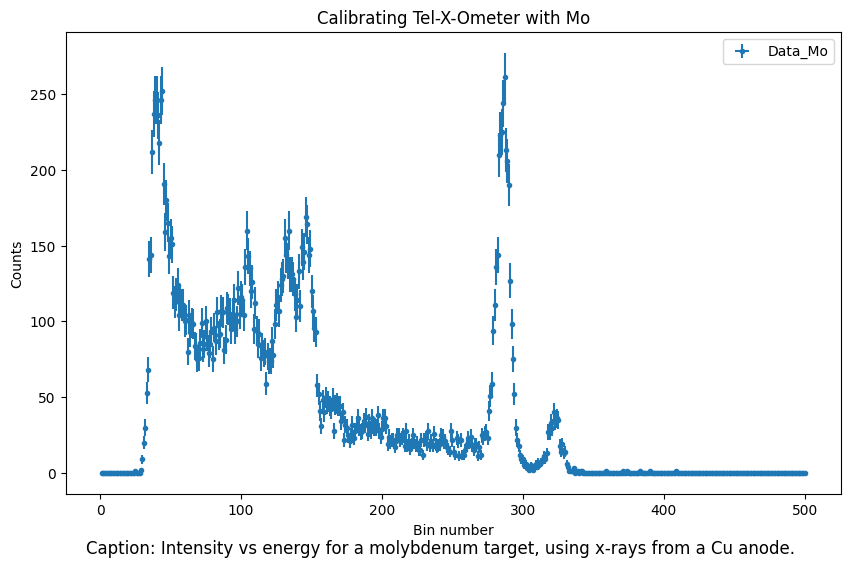

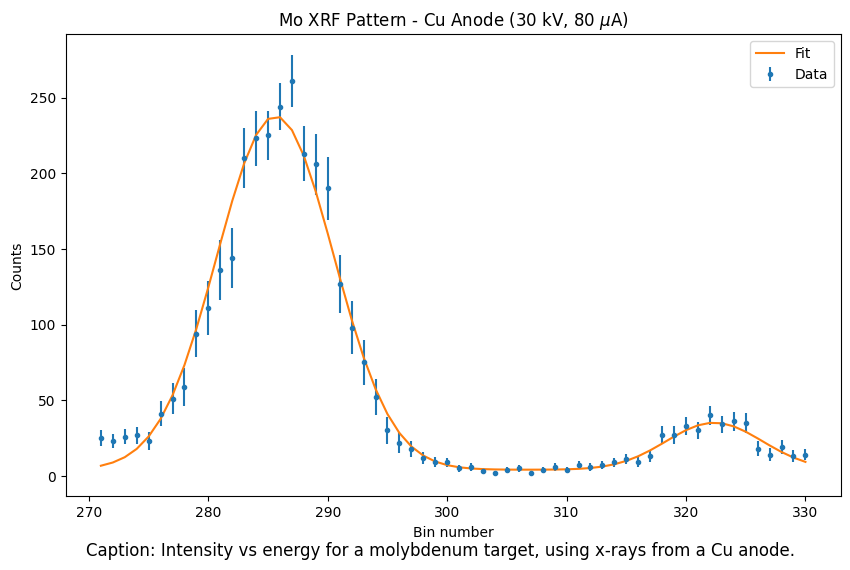

In [36]:
#KEY REMOVE FOR STUDENTS
#Import "xray_calibration_data.txt"
data = genfromtxt("xray_calibration_data.txt", delimiter='	', skip_header=0)
Bin = data[:, 0]
I_Mo = data[:, 2]
Bin_error = np.array([0.5 for x in Bin])
I_Mo_error = np.sqrt(I_Mo)

Bin_range = Bin[270:330]
Bin_error_range = Bin_error[270:330]
I_Mo_range = I_Mo[270:330]
I_Mo_error_range = I_Mo_error[270:330]

#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(Bin, I_Mo, xerr = Bin_error, yerr = I_Mo_error, fmt='.', label="Data_Mo")
plt.legend()
plt.xlabel('Bin number')
plt.ylabel('Counts')
plt.title('Calibrating Tel-X-Ometer with Mo')
plt.figtext(0.5, 0.01, "Caption: Intensity vs energy for a molybdenum target, using x-rays from a Cu anode.", wrap=True, horizontalalignment='center', fontsize=12)

#Make a Model Function
def Gaussian_Mo(x, a1, mu1, sigma1, a2, mu2, sigma2, y0):
    g = a1 * np.exp(-0.5 * (x - mu1)**2 / sigma1**2) + a2 * np.exp(-0.5 * (x - mu2)**2 / sigma2**2) + y0
    return g

#Preliminarily Fit the Data
guess_a1 = 260
guess_mu1 = 290
guess_sigma1 = 5
guess_a2 = 40
guess_mu2 = 320
guess_sigma2 = 5
guess_y0 = 1



guess=np.array([guess_a1, guess_mu1, guess_sigma1, guess_a2, guess_mu2, guess_sigma2, guess_y0])

uw_fits,uw_covs=curve_fit(Gaussian_Mo, Bin_range, I_Mo_range, p0=guess)
uw_sig=np.sqrt(np.diag(uw_covs))

#Calculate dg/dx
a1, mu1, sigma1, a2, mu2, sigma2, y0 = uw_fits
dg_dx = -((Bin_range - mu1) / sigma1**2) * a1 * np.exp(-0.5 * (Bin_range - mu1)**2 / sigma1**2) - ((Bin_range - mu2) / sigma2**2) * a2 * np.exp(-0.5 * (Bin_range - mu2)**2 / sigma2**2) 

#Calculate total error
sigmas= np.sqrt(I_Mo_error_range**2 + (dg_dx * Bin_error_range)**2)

#Perform weighted fit
fits, covs=curve_fit(Gaussian_Mo, Bin_range, I_Mo_range, p0=guess, sigma=sigmas)
stds=np.sqrt(np.diag(covs))


#Calculate reduced chi squared
Red_chi_sq_Mo= 1.0/(Bin_range.size-7.0) * np.sum((I_Mo_range - Gaussian_Mo(Bin_range, *fits))**2/sigmas**2)
print(f'Reduced Chi Squared = {Red_chi_sq_Mo:.3f}')
print(f"a1 = {fits[0]:.3f} ± {stds[0]:.3f}")
print(f"mu1 = {fits[1]:.3f} ± {stds[1]:.3f}")
print(f"sigma1 = {fits[2]:.3f} ± {stds[2]:.3f}")
print(f"a2 = {fits[3]:.3f} ± {stds[3]:.3f}")
print(f"mu2 = {fits[4]:.3f} ± {stds[4]:.3f}")
print(f"sigma2 = {fits[5]:.3f} ± {stds[5]:.3f}")
print(f"y0 = {fits[6]:.3f} ± {stds[6]:.3f}")
                 

#Plot the fit with the data!
fit_I_Mo = Gaussian_Mo(Bin_range, *fits)
fig1=plt.figure(1, figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(Bin_range, I_Mo_range, yerr=sigmas, fmt='.', label="Data")
plt.plot(Bin_range, fit_I_Mo, '-', label="Fit")
plt.legend()
plt.xlabel('Bin number')
plt.ylabel('Counts')
plt.title(r'Mo XRF Pattern - Cu Anode (30 kV, 80 $\mu$A)')
plt.figtext(0.5, 0.01, "Caption: Intensity vs energy for a molybdenum target, using x-rays from a Cu anode.", wrap=True, horizontalalignment='center', fontsize=12)





## Titanium (Ti)

Reduced Chi Squared = 1.022
a1 = 15724.911 ± 140.616
mu1 = 75.529 ± 0.098
sigma1 = 4.755 ± 0.073
y0 = 457.644 ± 38.909


Text(0.5, 0.01, 'Caption: Intensity vs energy for a titanium target, using x-rays from a Cu anode.')

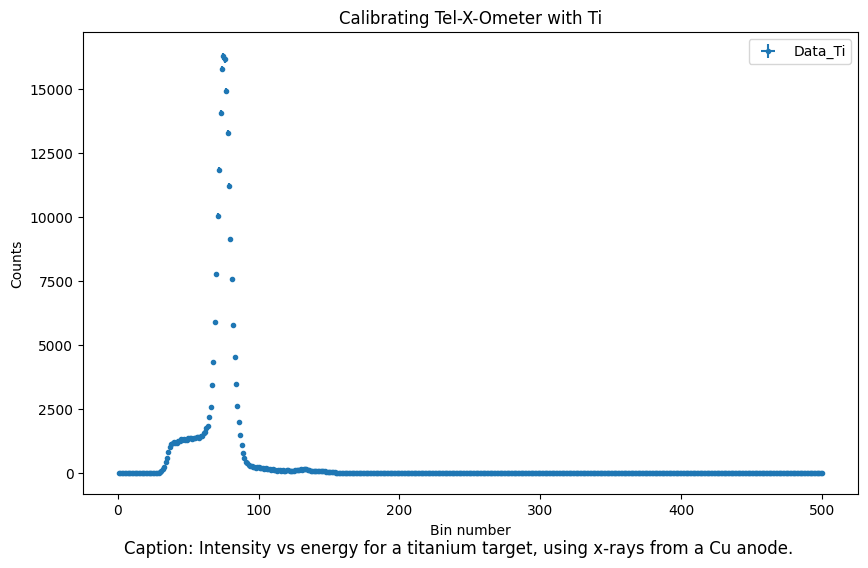

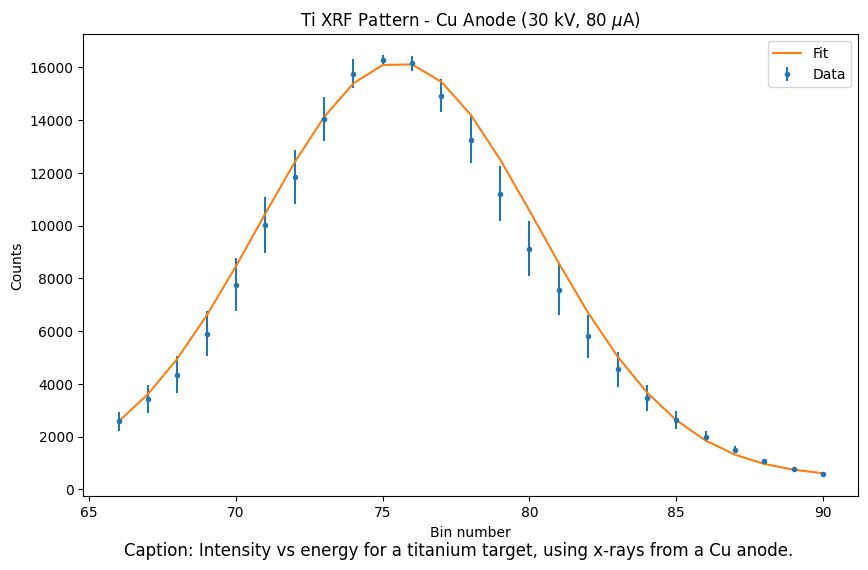

In [37]:
#KEY REMOVE FOR STUDENTS
#Import "xray_calibration_data.txt"
data = genfromtxt("xray_calibration_data.txt", delimiter='	', skip_header=0)
Bin = data[:, 0]
I_Ti = data[:, 3]
Bin_error = np.array([0.5 for x in Bin])
I_Ti_error = np.sqrt(I_Ti)

Bin_range = Bin[65:90]
Bin_error_range = Bin_error[65:90]
I_Ti_range = I_Ti[65:90]
I_Ti_error_range = I_Ti_error[65:90]

#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(Bin, I_Ti, xerr = Bin_error, yerr = I_Ti_error, fmt='.', label="Data_Ti")
plt.legend()
plt.xlabel('Bin number')
plt.ylabel('Counts')
plt.title('Calibrating Tel-X-Ometer with Ti')
plt.figtext(0.5, 0.01, "Caption: Intensity vs energy for a titanium target, using x-rays from a Cu anode.", wrap=True, horizontalalignment='center', fontsize=12)

#Make a Model Function
def Gaussian_Ti(x, a1, mu1, sigma1, y0):
    g = a1 * np.exp(-0.5 * (x - mu1)**2 / sigma1**2) + y0
    return g

#Preliminarily Fit the Data
guess_a1 = 18000
guess_mu1 = 75
guess_sigma1 = 5
guess_y0 = 1



guess=np.array([guess_a1, guess_mu1, guess_sigma1, guess_y0])

uw_fits,uw_covs=curve_fit(Gaussian_Ti, Bin_range, I_Ti_range, p0=guess)
uw_sig=np.sqrt(np.diag(uw_covs))

#Calculate dg/dx
a1, mu1, sigma1, y0 = uw_fits
dg_dx = -((Bin_range - mu1) / sigma1**2) * a1 * np.exp(-0.5 * (Bin_range - mu1)**2 / sigma1**2)

#Calculate total error
sigmas= np.sqrt(I_Ti_error_range**2 + (dg_dx * Bin_error_range)**2)

#Perform weighted fit
fits, covs=curve_fit(Gaussian_Ti, Bin_range, I_Ti_range, p0=guess, sigma=sigmas)
stds=np.sqrt(np.diag(covs))


#Calculate reduced chi squared
Red_chi_sq_Ti= 1.0/(Bin_range.size-7.0) * np.sum((I_Ti_range - Gaussian_Ti(Bin_range, *fits))**2/sigmas**2)
print(f'Reduced Chi Squared = {Red_chi_sq_Ti:.3f}')
print(f"a1 = {fits[0]:.3f} ± {stds[0]:.3f}")
print(f"mu1 = {fits[1]:.3f} ± {stds[1]:.3f}")
print(f"sigma1 = {fits[2]:.3f} ± {stds[2]:.3f}")
print(f"y0 = {fits[3]:.3f} ± {stds[3]:.3f}")
                 

#Plot the fit with the data!
fit_I_Ti = Gaussian_Ti(Bin_range, *fits)
fig1=plt.figure(1, figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(Bin_range, I_Ti_range, yerr=sigmas, fmt='.', label="Data")
plt.plot(Bin_range, fit_I_Ti, '-', label="Fit")
plt.legend()
plt.xlabel('Bin number')
plt.ylabel('Counts')
plt.title(r'Ti XRF Pattern - Cu Anode (30 kV, 80 $\mu$A)')
plt.figtext(0.5, 0.01, "Caption: Intensity vs energy for a titanium target, using x-rays from a Cu anode.", wrap=True, horizontalalignment='center', fontsize=12)





## Calibration Fit

Reduced Chi Squared = 0.009
m = 0.06114 ± 0.00012
b = -0.02856 ± 0.02643


Text(0.5, 0.01, 'Caption: A typical calibration curve relating bin number of each Gaussian to x-ray energy. Note that 512 bins correspond to approximately 30 keV, and 1024 bins to approximately 60 keV.')

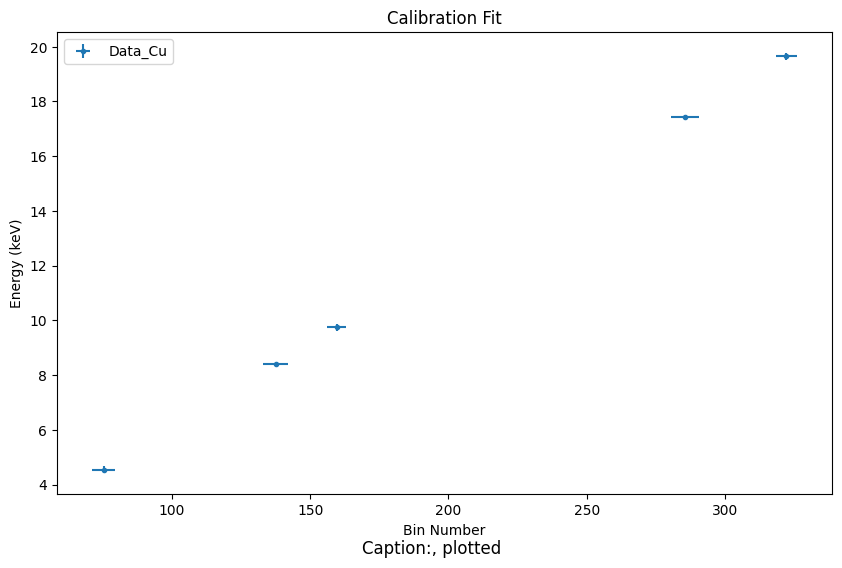

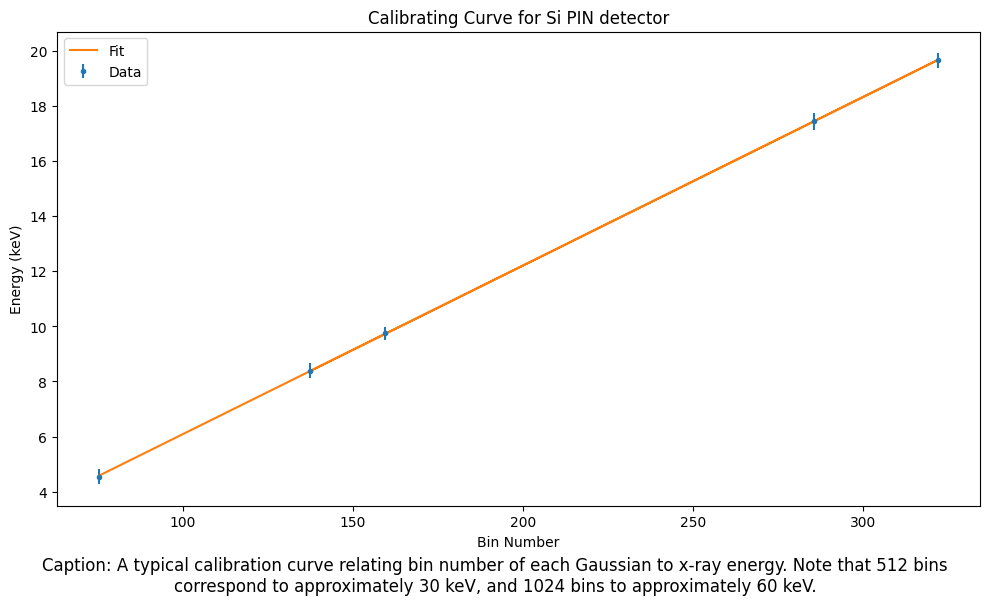

In [5]:
#KEY REMOVE FOR STUDENTS
#Import "CalibrationFit.txt"
data = genfromtxt("CalibrationFit.txt", delimiter=' ', skip_header=0)
Bin = data[:, 0]
Bin_error = data[:, 1]
E = data[:, 2]
E_error = data[:, 3]


#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(Bin, E, xerr = Bin_error, yerr = E_error, fmt='.', label="Data_Cu")
plt.legend()
plt.xlabel('Bin Number')
plt.ylabel('Energy (keV)')
plt.title('Calibration Fit')
plt.figtext(0.5, 0.01, "Caption:, plotted", wrap=True, horizontalalignment='center', fontsize=12)

#Make a Model Function
def Calibration_Fit(x, m, b):
    y = m * x + b
    return y

#Preliminarily Fit the Data
guess_m = 0.06
guess_b = 0



guess=np.array([guess_m, guess_b])

uw_fits,uw_covs=curve_fit(Calibration_Fit, Bin, E, p0=guess)
uw_sig=np.sqrt(np.diag(uw_covs))

m, b = uw_fits

#Calculate total error
sigmas= np.sqrt(E_error**2 + (m * Bin_error)**2)

#Perform weighted fit
fits, covs=curve_fit(Calibration_Fit, Bin, E, p0=guess, sigma=sigmas)
stds=np.sqrt(np.diag(covs))


#Calculate reduced chi squared
Red_chi_sq_calibration= 1.0/(Bin.size-2.0) * np.sum((E - Calibration_Fit(Bin, *fits))**2/sigmas**2)
print(f'Reduced Chi Squared = {Red_chi_sq_calibration:.3f}')
print(f"m = {fits[0]:.5f} ± {stds[0]:.5f}")
print(f"b = {fits[1]:.5f} ± {stds[1]:.5f}")
                 

#Plot the fit with the data!
fit_E = Calibration_Fit(Bin, *fits)
fig1=plt.figure(1, figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(Bin, E, yerr=sigmas, fmt='.', label="Data")
plt.plot(Bin, fit_E, '-', label="Fit")
plt.legend()
plt.xlabel('Bin Number')
plt.ylabel('Energy (keV)')
plt.title('Calibrating Curve for Si PIN detector')
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.figtext(0.5, 0.01, "Caption: A typical calibration curve relating bin number of each Gaussian to x-ray energy. Note that 512 bins correspond to approximately 30 keV, and 1024 bins to approximately 60 keV.", wrap=True, horizontalalignment='center', fontsize=12)



## Elements

### Cobalt (Co)

Reduced Chi Squared = 0.156
a1 = 9111.713 ± 46.378
mu1 = 114.330 ± 0.049
sigma1 = 3.932 ± 0.037
a2 = 705.276 ± 21.232
mu2 = 126.377 ± 0.118
sigma2 = 2.440 ± 0.113
y0 = 921.847 ± 18.284


Text(0.5, 0.01, 'Caption: Intensity vs energy for a cobalt target, using x-rays from a Cu anode.')

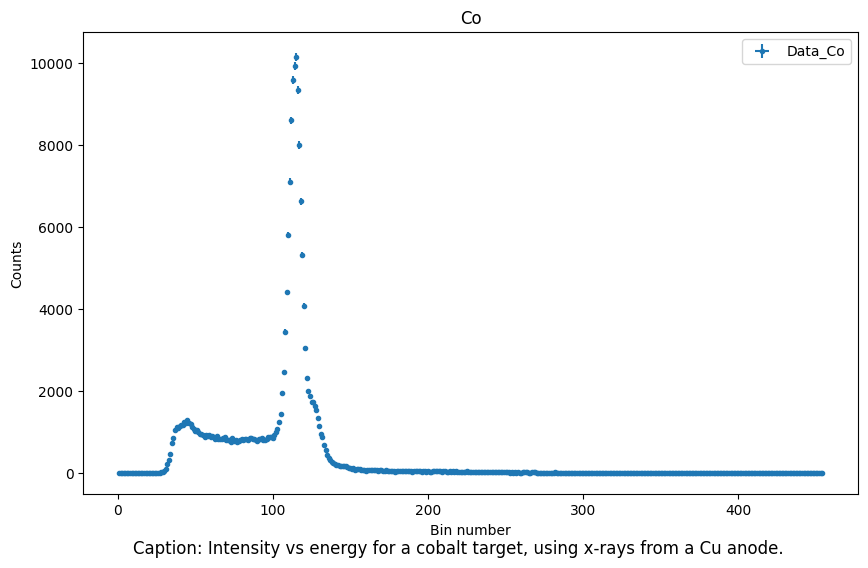

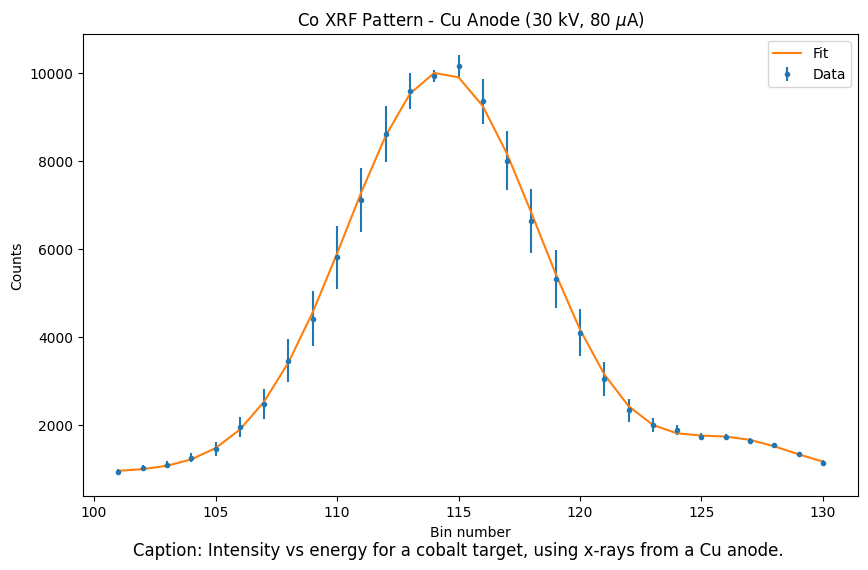

In [32]:
#KEY REMOVE FOR STUDENTS
#Import "Elements.txt"
data = genfromtxt("Elements.txt", delimiter='	', skip_header=0)
Bin = data[:, 0]
I_Co = data[:, 1]
Bin_error = np.array([0.5 for x in Bin])
I_Co_error = np.sqrt(I_Co)

Bin_range = Bin[100:130]
Bin_error_range = Bin_error[100:130]
I_Co_range = I_Co[100:130]
I_Co_error_range = I_Co_error[100:130]

#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(Bin, I_Co, xerr = Bin_error, yerr = I_Co_error, fmt='.', label="Data_Co")
plt.legend()
plt.xlabel('Bin number')
plt.ylabel('Counts')
plt.title('Co')
plt.figtext(0.5, 0.01, "Caption: Intensity vs energy for a cobalt target, using x-rays from a Cu anode.", wrap=True, horizontalalignment='center', fontsize=12)

#Make a Model Function
def Gaussian_Co(x, a1, mu1, sigma1, a2, mu2, sigma2, y0):
    g = a1 * np.exp(-0.5 * (x - mu1)**2 / sigma1**2) + a2 * np.exp(-0.5 * (x - mu2)**2 / sigma2**2) + y0
    return g

#Preliminarily Fit the Data
guess_a1 = 10100
guess_mu1 = 116
guess_sigma1 = 5
guess_a2 = 2000
guess_mu2 = 126
guess_sigma2 = 5
guess_y0 = 1



guess=np.array([guess_a1, guess_mu1, guess_sigma1, guess_a2, guess_mu2, guess_sigma2, guess_y0])

uw_fits,uw_covs=curve_fit(Gaussian_Co, Bin_range, I_Co_range, p0=guess)
uw_sig=np.sqrt(np.diag(uw_covs))

#Calculate dg/dx
a1, mu1, sigma1, a2, mu2, sigma2, y0 = uw_fits
dg_dx = -((Bin_range - mu1) / sigma1**2) * a1 * np.exp(-0.5 * (Bin_range - mu1)**2 / sigma1**2) - ((Bin_range - mu2) / sigma2**2) * a2 * np.exp(-0.5 * (Bin_range - mu2)**2 / sigma2**2) 

#Calculate total error
sigmas= np.sqrt(I_Co_error_range**2 + (dg_dx * Bin_error_range)**2)

#Perform weighted fit
fits, covs=curve_fit(Gaussian_Co, Bin_range, I_Co_range, p0=guess, sigma=sigmas)
stds=np.sqrt(np.diag(covs))


#Calculate reduced chi squared
Red_chi_sq_Co= 1.0/(Bin_range.size-7.0) * np.sum((I_Co_range - Gaussian_Co(Bin_range, *fits))**2/sigmas**2)
print(f'Reduced Chi Squared = {Red_chi_sq_Co:.3f}')
print(f"a1 = {fits[0]:.3f} ± {stds[0]:.3f}")
print(f"mu1 = {fits[1]:.3f} ± {stds[1]:.3f}")
print(f"sigma1 = {fits[2]:.3f} ± {stds[2]:.3f}")
print(f"a2 = {fits[3]:.3f} ± {stds[3]:.3f}")
print(f"mu2 = {fits[4]:.3f} ± {stds[4]:.3f}")
print(f"sigma2 = {fits[5]:.3f} ± {stds[5]:.3f}")
print(f"y0 = {fits[6]:.3f} ± {stds[6]:.3f}")
                 

#Plot the fit with the data!
fit_I_Co = Gaussian_Co(Bin_range, *fits)
fig1=plt.figure(1, figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(Bin_range, I_Co_range, yerr=sigmas, fmt='.', label="Data")
plt.plot(Bin_range, fit_I_Co, '-', label="Fit")
plt.legend()
plt.xlabel('Bin number')
plt.ylabel('Counts')
plt.title(r'Co XRF Pattern - Cu Anode (30 kV, 80 $\mu$A)')
plt.figtext(0.5, 0.01, "Caption: Intensity vs energy for a cobalt target, using x-rays from a Cu anode.", wrap=True, horizontalalignment='center', fontsize=12)





### Nickel (Ni)

Reduced Chi Squared = 2.241
a1 = 5457.933 ± 95.805
mu1 = 123.234 ± 0.269
sigma1 = 5.179 ± 0.158
a2 = 739.496 ± 91.335
mu2 = 136.464 ± 1.013
sigma2 = 4.442 ± 0.574
y0 = 141.619 ± 15.267


Text(0.5, 0.01, 'Caption: Intensity vs energy for a nickel target, using x-rays from a Cu anode.')

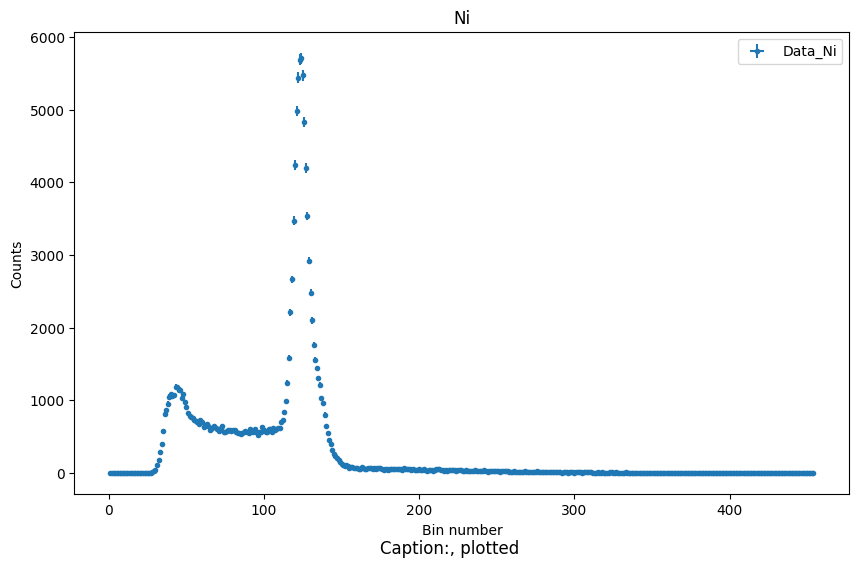

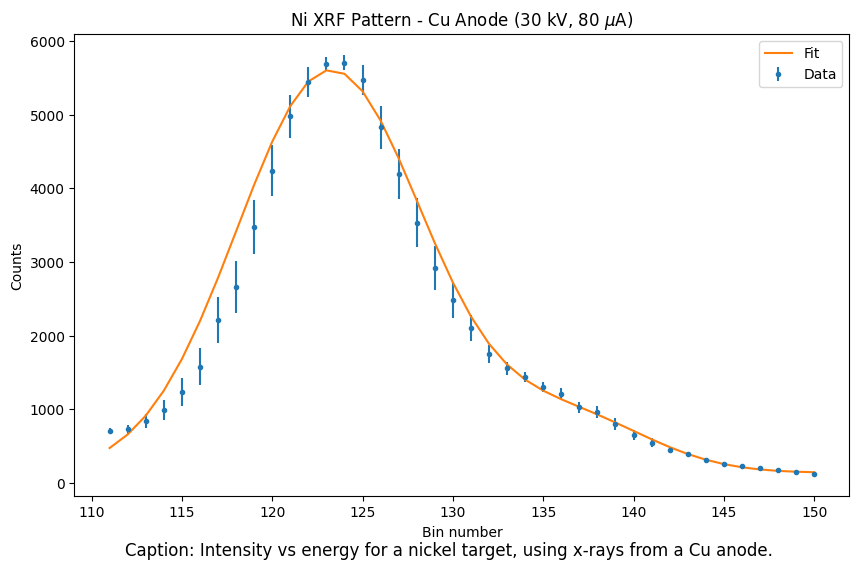

In [38]:
#KEY REMOVE FOR STUDENTS
#Import "Elements.txt"
data = genfromtxt("Elements.txt", delimiter='	', skip_header=0)
Bin = data[:, 0]
I_Ni = data[:, 2]
Bin_error = np.array([0.5 for x in Bin])
I_Ni_error = np.sqrt(I_Ni)

Bin_range = Bin[110:150]
Bin_error_range = Bin_error[110:150]
I_Ni_range = I_Ni[110:150]
I_Ni_error_range = I_Ni_error[110:150]

#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(Bin, I_Ni, xerr = Bin_error, yerr = I_Ni_error, fmt='.', label="Data_Ni")
plt.legend()
plt.xlabel('Bin number')
plt.ylabel('Counts')
plt.title('Ni')
plt.figtext(0.5, 0.01, "Caption:, plotted", wrap=True, horizontalalignment='center', fontsize=12)

#Make a Model Function
def Gaussian_Ni(x, a1, mu1, sigma1, a2, mu2, sigma2, y0):
    g = a1 * np.exp(-0.5 * (x - mu1)**2 / sigma1**2) + a2 * np.exp(-0.5 * (x - mu2)**2 / sigma2**2) + y0
    return g

#Preliminarily Fit the Data
guess_a1 = 5800
guess_mu1 = 123
guess_sigma1 = 5
guess_a2 = 1000
guess_mu2 = 137
guess_sigma2 = 5
guess_y0 = 1



guess=np.array([guess_a1, guess_mu1, guess_sigma1, guess_a2, guess_mu2, guess_sigma2, guess_y0])

uw_fits,uw_covs=curve_fit(Gaussian_Ni, Bin_range, I_Ni_range, p0=guess)
uw_sig=np.sqrt(np.diag(uw_covs))

#Calculate dg/dx
a1, mu1, sigma1, a2, mu2, sigma2, y0 = uw_fits
dg_dx = -((Bin_range - mu1) / sigma1**2) * a1 * np.exp(-0.5 * (Bin_range - mu1)**2 / sigma1**2) - ((Bin_range - mu2) / sigma2**2) * a2 * np.exp(-0.5 * (Bin_range - mu2)**2 / sigma2**2)

#Calculate total error
sigmas= np.sqrt(I_Ni_error_range**2 + (dg_dx * Bin_error_range)**2)

#Perform weighted fit
fits, covs=curve_fit(Gaussian_Ni, Bin_range, I_Ni_range, p0=guess, sigma=sigmas)
stds=np.sqrt(np.diag(covs))


#Calculate reduced chi squared
Red_chi_sq_swing= 1.0/(Bin_range.size-4.0) * np.sum((I_Ni_range - Gaussian_Ni(Bin_range, *fits))**2/sigmas**2)
print(f'Reduced Chi Squared = {Red_chi_sq_swing:.3f}')
print(f"a1 = {fits[0]:.3f} ± {stds[0]:.3f}")
print(f"mu1 = {fits[1]:.3f} ± {stds[1]:.3f}")
print(f"sigma1 = {fits[2]:.3f} ± {stds[2]:.3f}")
print(f"a2 = {fits[3]:.3f} ± {stds[3]:.3f}")
print(f"mu2 = {fits[4]:.3f} ± {stds[4]:.3f}")
print(f"sigma2 = {fits[5]:.3f} ± {stds[5]:.3f}")
print(f"y0 = {fits[6]:.3f} ± {stds[6]:.3f}")
                 

#Plot the fit with the data!
fit_I_Ni = Gaussian_Ni(Bin_range, *fits)
fig1=plt.figure(1, figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(Bin_range, I_Ni_range, yerr=sigmas, fmt='.', label="Data")
plt.plot(Bin_range, fit_I_Ni, '-', label="Fit")
plt.legend()
plt.xlabel('Bin number')
plt.ylabel('Counts')
plt.title(r'Ni XRF Pattern - Cu Anode (30 kV, 80 $\mu$A)')
plt.figtext(0.5, 0.01, "Caption: Intensity vs energy for a nickel target, using x-rays from a Cu anode.", wrap=True, horizontalalignment='center', fontsize=12)





### Copper (Cu)

Reduced Chi Squared = 0.323
a1 = 1028.478 ± 29.209
mu1 = 133.028 ± 0.440
sigma1 = 5.400 ± 0.255
a2 = 3061.807 ± 68.342
mu2 = 142.438 ± 0.112
sigma2 = 3.479 ± 0.078
y0 = 410.535 ± 8.043


Text(0.5, 0.01, 'Caption: Intensity vs energy for a copper target, using x-rays from a Cu anode.')

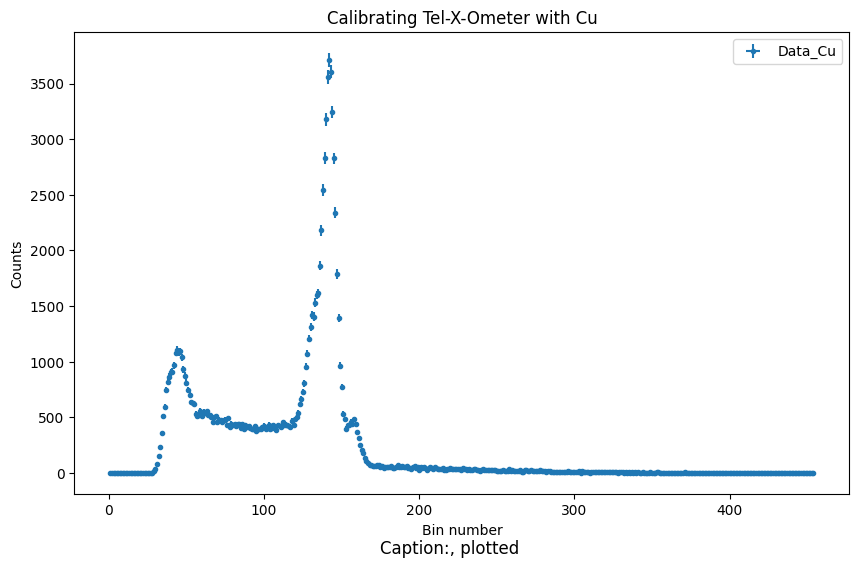

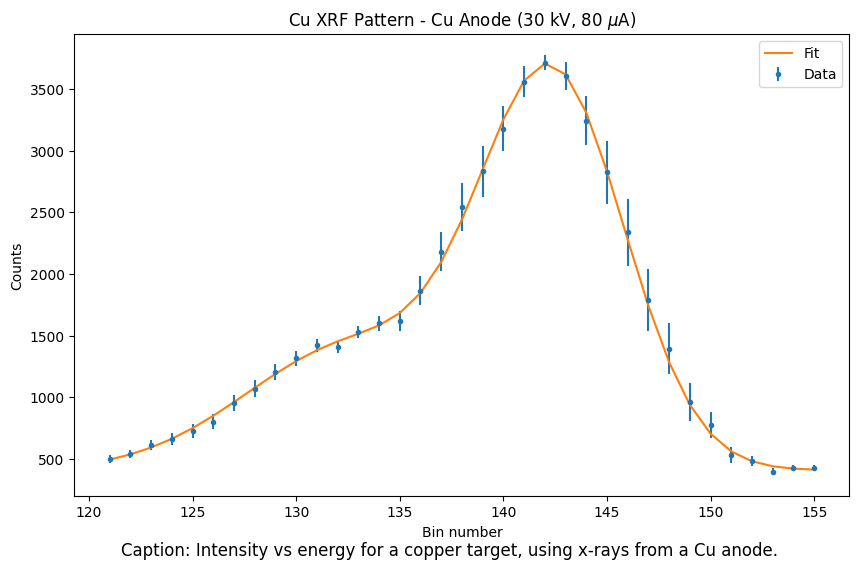

In [39]:
#KEY REMOVE FOR STUDENTS
#Import "Elements.txt"
data = genfromtxt("Elements.txt", delimiter='	', skip_header=0)
Bin = data[:, 0]
I_Cu = data[:, 4]
Bin_error = np.array([0.5 for x in Bin])
I_Cu_error = np.sqrt(I_Cu)

Bin_range = Bin[120:155]
Bin_error_range = Bin_error[120:155]
I_Cu_range = I_Cu[120:155]
I_Cu_error_range = I_Cu_error[120:155]

#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(Bin, I_Cu, xerr = Bin_error, yerr = I_Cu_error, fmt='.', label="Data_Cu")
plt.legend()
plt.xlabel('Bin number')
plt.ylabel('Counts')
plt.title('Calibrating Tel-X-Ometer with Cu')
plt.figtext(0.5, 0.01, "Caption:, plotted", wrap=True, horizontalalignment='center', fontsize=12)

#Make a Model Function
def Gaussian_Cu(x, a1, mu1, sigma1, a2, mu2, sigma2, y0):
    g = a1 * np.exp(-0.5 * (x - mu1)**2 / sigma1**2) + a2 * np.exp(-0.5 * (x - mu2)**2 / sigma2**2) + y0
    return g

#Preliminarily Fit the Data
guess_a1 = 4000
guess_mu1 = 130
guess_sigma1 = 5
guess_a2 = 600
guess_mu2 = 150
guess_sigma2 = 5
guess_y0 = 1



guess=np.array([guess_a1, guess_mu1, guess_sigma1, guess_a2, guess_mu2, guess_sigma2, guess_y0])

uw_fits,uw_covs=curve_fit(Gaussian_Cu, Bin_range, I_Cu_range, p0=guess)
uw_sig=np.sqrt(np.diag(uw_covs))

#Calculate dg/dx
a1, mu1, sigma1, a2, mu2, sigma2, y0 = uw_fits
dg_dx = -((Bin_range - mu1) / sigma1**2) * a1 * np.exp(-0.5 * (Bin_range - mu1)**2 / sigma1**2) - ((Bin_range - mu2) / sigma2**2) * a2 * np.exp(-0.5 * (Bin_range - mu2)**2 / sigma2**2) 

#Calculate total error
sigmas= np.sqrt(I_Cu_error_range**2 + (dg_dx * Bin_error_range)**2)

#Perform weighted fit
fits, covs=curve_fit(Gaussian_Cu, Bin_range, I_Cu_range, p0=guess, sigma=sigmas)
stds=np.sqrt(np.diag(covs))


#Calculate reduced chi squared
Red_chi_sq_Cu= 1.0/(Bin_range.size-7.0) * np.sum((I_Cu_range - Gaussian_Cu(Bin_range, *fits))**2/sigmas**2)
print(f'Reduced Chi Squared = {Red_chi_sq_Cu:.3f}')
print(f"a1 = {fits[0]:.3f} ± {stds[0]:.3f}")
print(f"mu1 = {fits[1]:.3f} ± {stds[1]:.3f}")
print(f"sigma1 = {fits[2]:.3f} ± {stds[2]:.3f}")
print(f"a2 = {fits[3]:.3f} ± {stds[3]:.3f}")
print(f"mu2 = {fits[4]:.3f} ± {stds[4]:.3f}")
print(f"sigma2 = {fits[5]:.3f} ± {stds[5]:.3f}")
print(f"y0 = {fits[6]:.3f} ± {stds[6]:.3f}")
                 

#Plot the fit with the data!
fit_I_Cu = Gaussian_Cu(Bin_range, *fits)
fig1=plt.figure(1, figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(Bin_range, I_Cu_range, yerr=sigmas, fmt='.', label="Data")
plt.plot(Bin_range, fit_I_Cu, '-', label="Fit")
plt.legend()
plt.xlabel('Bin number')
plt.ylabel('Counts')
plt.title(r'Cu XRF Pattern - Cu Anode (30 kV, 80 $\mu$A)')
plt.figtext(0.5, 0.01, "Caption: Intensity vs energy for a copper target, using x-rays from a Cu anode.", wrap=True, horizontalalignment='center', fontsize=12)





### Zinc (Zn)

Reduced Chi Squared = 0.341
a1 = 1274.178 ± 47.933
mu1 = 131.485 ± 0.424
sigma1 = 5.142 ± 0.472
a2 = 3471.028 ± 75.554
mu2 = 142.415 ± 0.163
sigma2 = 3.968 ± 0.104
a3 = 389.102 ± 32.976
mu3 = 157.061 ± 0.150
sigma3 = 4.186 ± 0.389
y0 = 71.424 ± 34.835


Text(0.5, 0.01, 'Caption:, plotted')

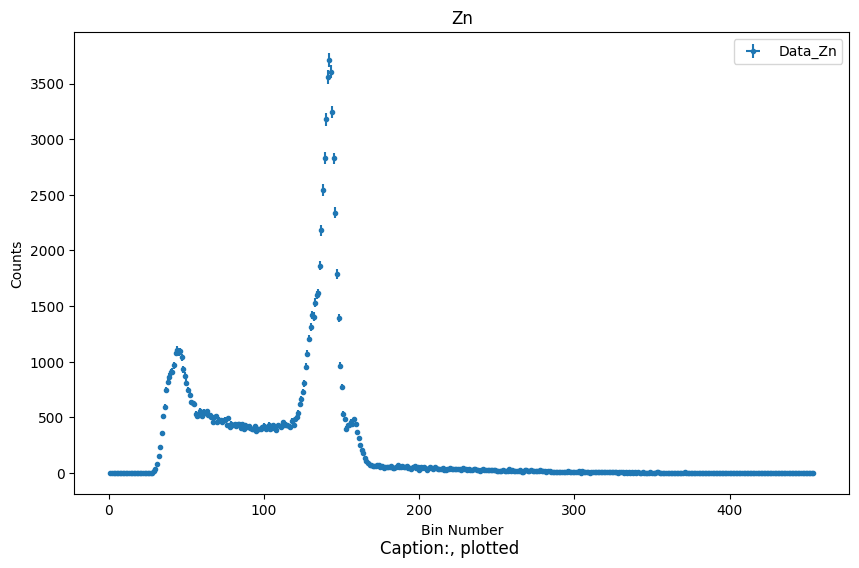

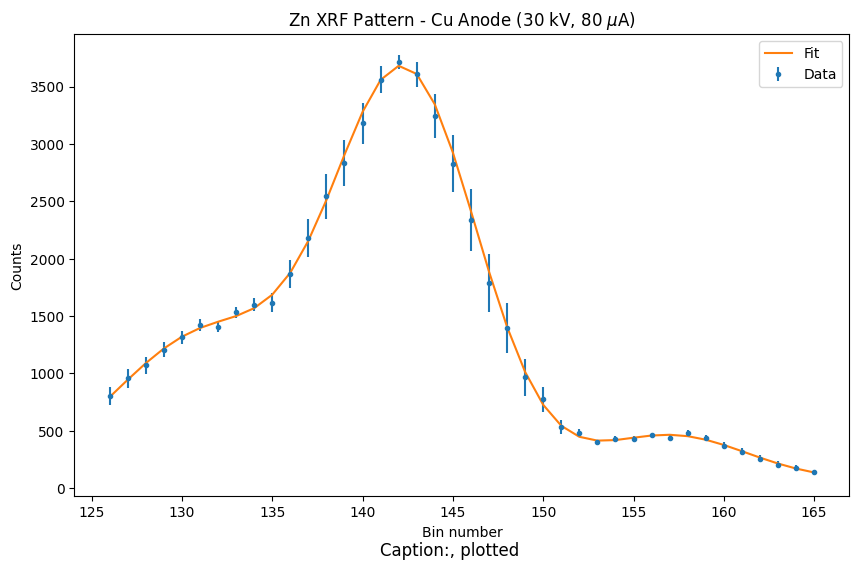

In [40]:
#KEY REMOVE FOR STUDENTS
#Import "Elements.txt"
data = genfromtxt("Elements.txt", delimiter='	', skip_header=0)
Bin = data[:, 0]
I_Zn = data[:, 4]
Bin_error = np.array([0.5 for x in Bin])
I_Zn_error = np.sqrt(I_Zn)

Bin_range = Bin[125:165]
Bin_error_range = Bin_error[125:165]
I_Zn_range = I_Zn[125:165]
I_Zn_error_range = I_Zn_error[125:165]

#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(Bin, I_Zn, xerr = Bin_error, yerr = I_Zn_error, fmt='.', label="Data_Zn")
plt.legend()
plt.xlabel('Bin Number')
plt.ylabel('Counts')
plt.title('Zn')
plt.figtext(0.5, 0.01, "Caption:, plotted", wrap=True, horizontalalignment='center', fontsize=12)

#Make a Model Function
def Gaussian_Zn(x, a1, mu1, sigma1, a2, mu2, sigma2, a3, mu3, sigma3, y0):
    g = a1 * np.exp(-0.5 * (x - mu1)**2 / sigma1**2) + a2 * np.exp(-0.5 * (x - mu2)**2 / sigma2**2) + a3 * np.exp(-0.5 * (x - mu3)**2 / sigma3**2) + y0
    return g

#Preliminarily Fit the Data
guess_a1 = 1400
guess_mu1 = 131
guess_sigma1 = 5
guess_a2 = 3600
guess_mu2 = 142
guess_sigma2 = 5
guess_a3 = 500
guess_mu3 = 158
guess_sigma3 = 5
guess_y0 = 1



guess=np.array([guess_a1, guess_mu1, guess_sigma1, guess_a2, guess_mu2, guess_sigma2, guess_a3, guess_mu3, guess_sigma3, guess_y0])

uw_fits,uw_covs=curve_fit(Gaussian_Zn, Bin_range, I_Zn_range, p0=guess)
uw_sig=np.sqrt(np.diag(uw_covs))

#Calculate dg/dx
a1, mu1, sigma1, a2, mu2, sigma2, a3, mu3, sigma3, y0 = uw_fits
dg_dx = -((Bin_range - mu1) / sigma1**2) * a1 * np.exp(-0.5 * (Bin_range - mu1)**2 / sigma1**2) - ((Bin_range - mu2) / sigma2**2) * a2 * np.exp(-0.5 * (Bin_range - mu2)**2 / sigma2**2) - ((Bin_range - mu3) / sigma3**2) * a3 * np.exp(-0.5 * (Bin_range - mu3)**2 / sigma3**2) 

#Calculate total error
sigmas= np.sqrt(I_Zn_error_range**2 + (dg_dx * Bin_error_range)**2)

#Perform weighted fit
fits, covs=curve_fit(Gaussian_Zn, Bin_range, I_Zn_range, p0=guess, sigma=sigmas)
stds=np.sqrt(np.diag(covs))


#Calculate reduced chi squared
Red_chi_sq_Zn= 1.0/(Bin_range.size-10.0) * np.sum((I_Zn_range - Gaussian_Zn(Bin_range, *fits))**2/sigmas**2)
print(f'Reduced Chi Squared = {Red_chi_sq_Zn:.3f}')
print(f"a1 = {fits[0]:.3f} ± {stds[0]:.3f}")
print(f"mu1 = {fits[1]:.3f} ± {stds[1]:.3f}")
print(f"sigma1 = {fits[2]:.3f} ± {stds[2]:.3f}")
print(f"a2 = {fits[3]:.3f} ± {stds[3]:.3f}")
print(f"mu2 = {fits[4]:.3f} ± {stds[4]:.3f}")
print(f"sigma2 = {fits[5]:.3f} ± {stds[5]:.3f}")
print(f"a3 = {fits[6]:.3f} ± {stds[6]:.3f}")
print(f"mu3 = {fits[7]:.3f} ± {stds[7]:.3f}")
print(f"sigma3 = {fits[8]:.3f} ± {stds[8]:.3f}")
print(f"y0 = {fits[9]:.3f} ± {stds[9]:.3f}")
                 

#Plot the fit with the data!
fit_I_Zn = Gaussian_Zn(Bin_range, *fits)
fig1=plt.figure(1, figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(Bin_range, I_Zn_range, yerr=sigmas, fmt='.', label="Data")
plt.plot(Bin_range, fit_I_Zn, '-', label="Fit")
plt.legend()
plt.xlabel('Bin number')
plt.ylabel('Counts')
plt.title(r'Zn XRF Pattern - Cu Anode (30 kV, 80 $\mu$A)')
plt.figtext(0.5, 0.01, "Caption:, plotted", wrap=True, horizontalalignment='center', fontsize=12)





### Vanadium (V)

Reduced Chi Squared = 1.595
a1 = 6400.886 ± 88.134
mu1 = 82.617 ± 0.112
sigma1 = 5.024 ± 0.072
y0 = 177.890 ± 12.629


Text(0.5, 0.01, 'Caption: Intensity vs energy for a vanadium target, using x-rays from a Cu anode.')

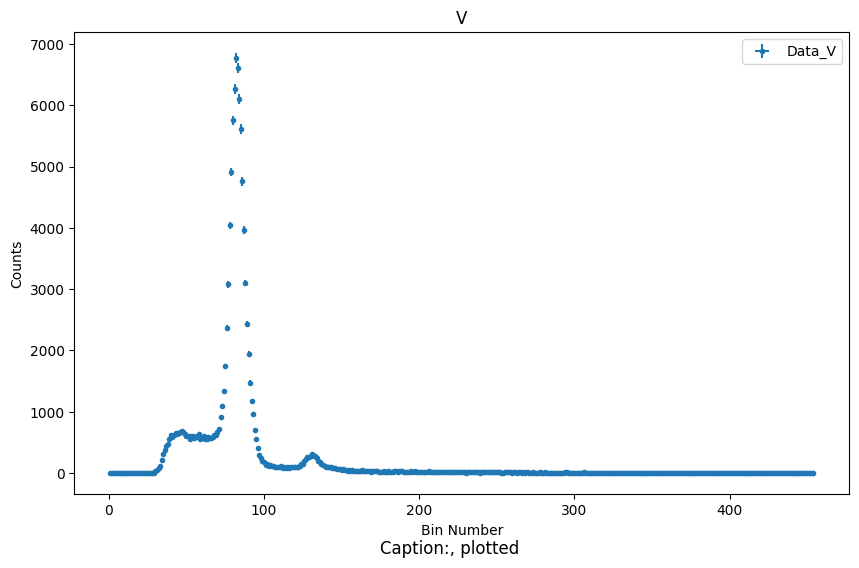

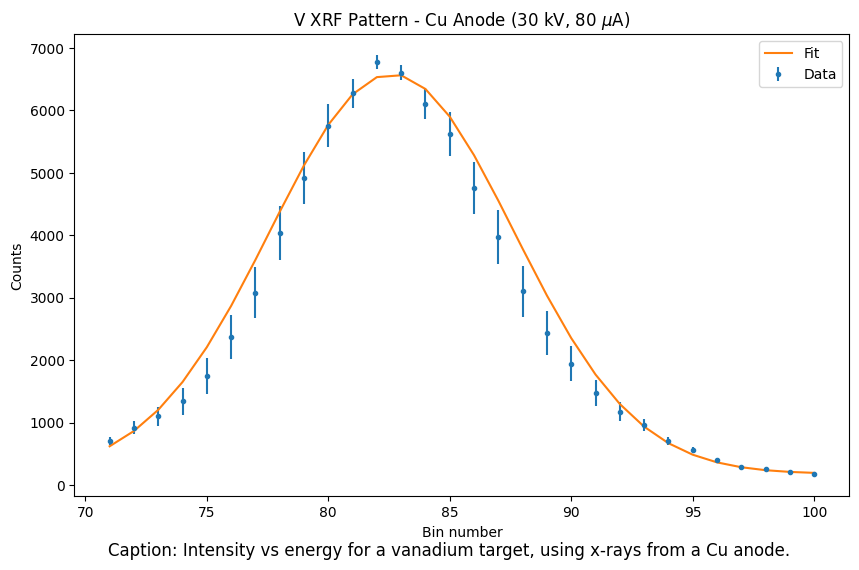

In [41]:
#KEY REMOVE FOR STUDENTS
#Import "Elements.txt"
data = genfromtxt("Elements.txt", delimiter='	', skip_header=0)
Bin = data[:, 0]
I_V = data[:, 5]
Bin_error = np.array([0.5 for x in Bin])
I_V_error = np.sqrt(I_V)

Bin_range = Bin[70:100]
Bin_error_range = Bin_error[70:100]
I_V_range = I_V[70:100]
I_V_error_range = I_V_error[70:100]

#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(Bin, I_V, xerr = Bin_error, yerr = I_V_error, fmt='.', label="Data_V")
plt.legend()
plt.xlabel('Bin Number')
plt.ylabel('Counts')
plt.title('V')
plt.figtext(0.5, 0.01, "Caption:, plotted", wrap=True, horizontalalignment='center', fontsize=12)

#Make a Model Function
def Gaussian_V(x, a1, mu1, sigma1, y0):
    g = a1 * np.exp(-0.5 * (x - mu1)**2 / sigma1**2) + y0
    return g

#Preliminarily Fit the Data
guess_a1 = 7000
guess_mu1 = 82
guess_sigma1 = 5
guess_y0 = 1



guess=np.array([guess_a1, guess_mu1, guess_sigma1, guess_y0])

uw_fits,uw_covs=curve_fit(Gaussian_V, Bin_range, I_V_range, p0=guess)
uw_sig=np.sqrt(np.diag(uw_covs))

#Calculate dg/dx
a1, mu1, sigma1, y0 = uw_fits
dg_dx = -((Bin_range - mu1) / sigma1**2) * a1 * np.exp(-0.5 * (Bin_range - mu1)**2 / sigma1**2) 
#Calculate total error
sigmas= np.sqrt(I_V_error_range**2 + (dg_dx * Bin_error_range)**2)

#Perform weighted fit
fits, covs=curve_fit(Gaussian_V, Bin_range, I_V_range, p0=guess, sigma=sigmas)
stds=np.sqrt(np.diag(covs))


#Calculate reduced chi squared
Red_chi_sq_V= 1.0/(Bin_range.size-4.0) * np.sum((I_V_range - Gaussian_V(Bin_range, *fits))**2/sigmas**2)
print(f'Reduced Chi Squared = {Red_chi_sq_V:.3f}')
print(f"a1 = {fits[0]:.3f} ± {stds[0]:.3f}")
print(f"mu1 = {fits[1]:.3f} ± {stds[1]:.3f}")
print(f"sigma1 = {fits[2]:.3f} ± {stds[2]:.3f}")
print(f"y0 = {fits[3]:.3f} ± {stds[3]:.3f}")
                 

#Plot the fit with the data!
fit_I_V = Gaussian_V(Bin_range, *fits)
fig1=plt.figure(1, figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(Bin_range, I_V_range, yerr=sigmas, fmt='.', label="Data")
plt.plot(Bin_range, fit_I_V, '-', label="Fit")
plt.legend()
plt.xlabel('Bin number')
plt.ylabel('Counts')
plt.title(r'V XRF Pattern - Cu Anode (30 kV, 80 $\mu$A)')
plt.figtext(0.5, 0.01, "Caption: Intensity vs energy for a vanadium target, using x-rays from a Cu anode.", wrap=True, horizontalalignment='center', fontsize=12)





### Chromium (Cr)

Reduced Chi Squared = 0.361
a1 = 5806.809 ± 75.023
mu1 = 90.053 ± 0.072
sigma1 = 3.862 ± 0.101
y0 = 957.088 ± 69.502


Text(0.5, 0.01, 'Caption: Intensity vs energy for a chromium target, using x-rays from a Cu anode.')

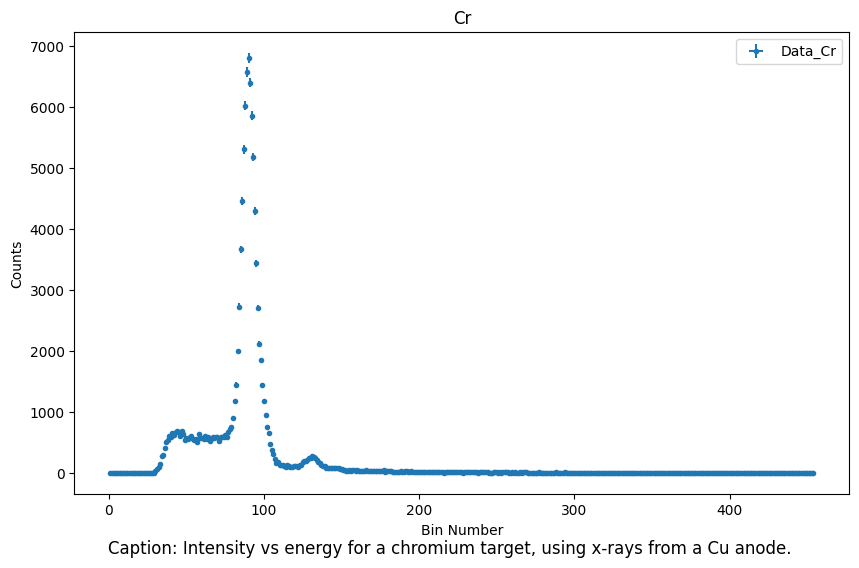

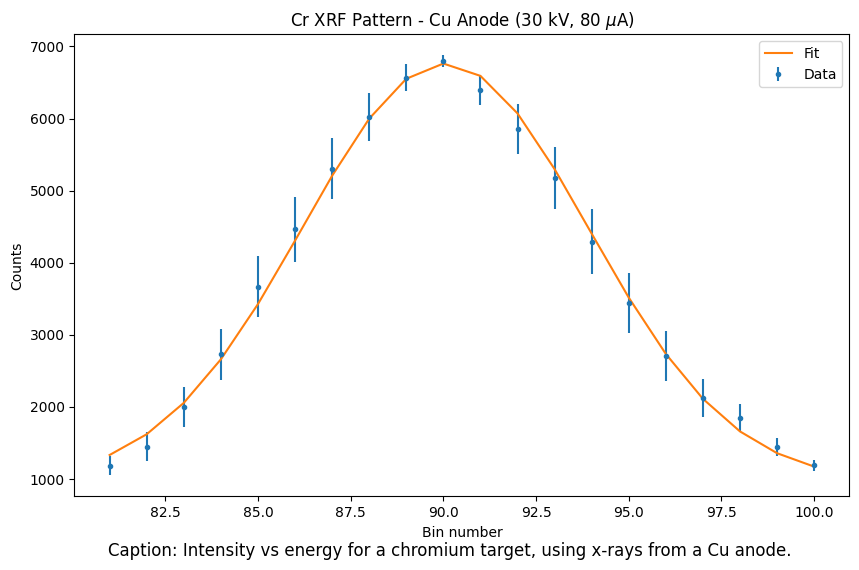

In [4]:
#KEY REMOVE FOR STUDENTS
#Import "Elements.txt"
data = genfromtxt("Elements.txt", delimiter='	', skip_header=0)
Bin = data[:, 0]
I_Cr = data[:, 6]
Bin_error = np.array([0.5 for x in Bin])
I_Cr_error = np.sqrt(I_Cr)

Bin_range = Bin[80:100]
Bin_error_range = Bin_error[80:100]
I_Cr_range = I_Cr[80:100]
I_Cr_error_range = I_Cr_error[80:100]

#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(Bin, I_Cr, xerr = Bin_error, yerr = I_Cr_error, fmt='.', label="Data_Cr")
plt.legend()
plt.xlabel('Bin Number')
plt.ylabel('Counts')
plt.title('Cr')
plt.figtext(0.5, 0.01, "Caption: Intensity vs energy for a chromium target, using x-rays from a Cu anode.", wrap=True, horizontalalignment='center', fontsize=12)

#Make a Model Function
def Gaussian_Cr(x, a1, mu1, sigma1, y0):
    g = a1 * np.exp(-0.5 * (x - mu1)**2 / sigma1**2) + y0
    return g

#Preliminarily Fit the Data
guess_a1 = 7000
guess_mu1 = 90
guess_sigma1 = 5
guess_y0 = 1



guess=np.array([guess_a1, guess_mu1, guess_sigma1, guess_y0])

uw_fits,uw_covs=curve_fit(Gaussian_Cr, Bin_range, I_Cr_range, p0=guess)
uw_sig=np.sqrt(np.diag(uw_covs))

#Calculate dg/dx
a1, mu1, sigma1, y0 = uw_fits
dg_dx = -((Bin_range - mu1) / sigma1**2) * a1 * np.exp(-0.5 * (Bin_range - mu1)**2 / sigma1**2) 
#Calculate total error
sigmas= np.sqrt(I_Cr_error_range**2 + (dg_dx * Bin_error_range)**2)

#Perform weighted fit
fits, covs=curve_fit(Gaussian_Cr, Bin_range, I_Cr_range, p0=guess, sigma=sigmas)
stds=np.sqrt(np.diag(covs))


#Calculate reduced chi squared
Red_chi_sq_Cr= 1.0/(Bin_range.size-4.0) * np.sum((I_Cr_range - Gaussian_Cr(Bin_range, *fits))**2/sigmas**2)
print(f'Reduced Chi Squared = {Red_chi_sq_Cr:.3f}')
print(f"a1 = {fits[0]:.3f} ± {stds[0]:.3f}")
print(f"mu1 = {fits[1]:.3f} ± {stds[1]:.3f}")
print(f"sigma1 = {fits[2]:.3f} ± {stds[2]:.3f}")
print(f"y0 = {fits[3]:.3f} ± {stds[3]:.3f}")
                 

#Plot the fit with the data!
fit_I_Cr = Gaussian_Cr(Bin_range, *fits)
fig1=plt.figure(1, figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(Bin_range, I_Cr_range, yerr=sigmas, fmt='.', label="Data")
plt.plot(Bin_range, fit_I_Cr, '-', label="Fit")
plt.legend()
plt.xlabel('Bin number')
plt.ylabel('Counts')
plt.title(r'Cr XRF Pattern - Cu Anode (30 kV, 80 $\mu$A)')
plt.figtext(0.5, 0.01, "Caption: Intensity vs energy for a chromium target, using x-rays from a Cu anode.", wrap=True, horizontalalignment='center', fontsize=12)





### Manganese (Mn)

Reduced Chi Squared = 1.643
a1 = 5531.284 ± 94.088
mu1 = 98.129 ± 0.132
sigma1 = 4.170 ± 0.134
y0 = 666.717 ± 44.033


Text(0.5, 0.01, 'Caption: Intensity vs energy for a manganese target, using x-rays from a Cu anode.')

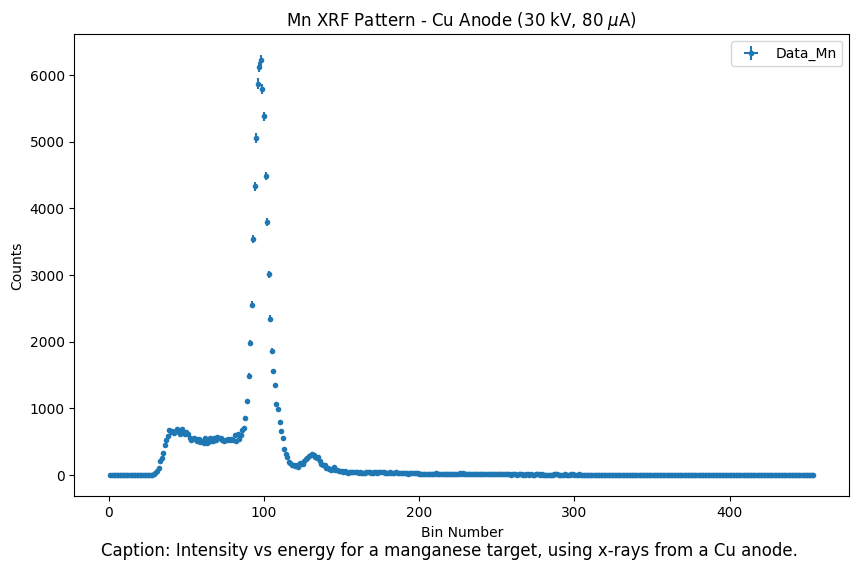

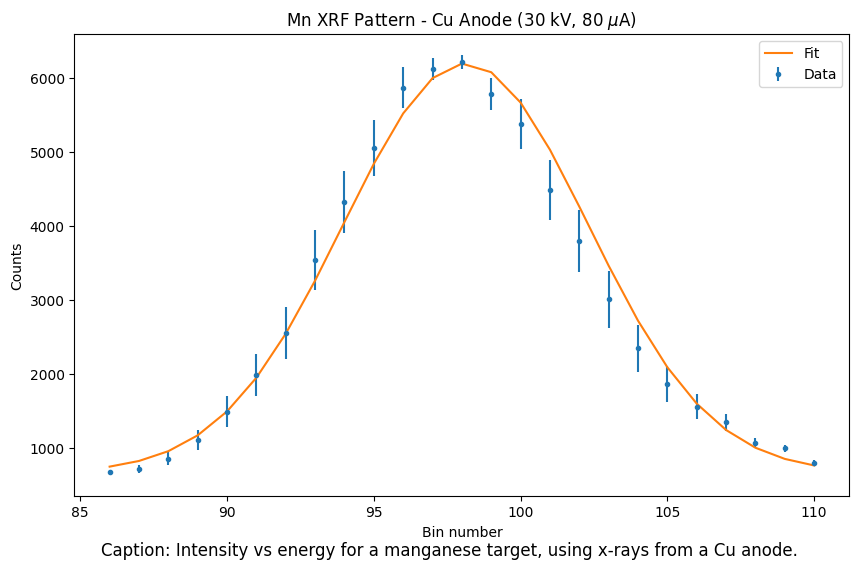

In [5]:
#KEY REMOVE FOR STUDENTS
#Import "Elements.txt"
data = genfromtxt("Elements.txt", delimiter='	', skip_header=0)
Bin = data[:, 0]
I_Mn = data[:, 7]
Bin_error = np.array([0.5 for x in Bin])
I_Mn_error = np.sqrt(I_Mn)

Bin_range = Bin[85:110]
Bin_error_range = Bin_error[85:110]
I_Mn_range = I_Mn[85:110]
I_Mn_error_range = I_Mn_error[85:110]

#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(Bin, I_Mn, xerr = Bin_error, yerr = I_Mn_error, fmt='.', label="Data_Mn")
plt.legend()
plt.xlabel('Bin Number')
plt.ylabel('Counts')
plt.title(r'Mn XRF Pattern - Cu Anode (30 kV, 80 $\mu$A)')
plt.figtext(0.5, 0.01, "Caption: Intensity vs energy for a manganese target, using x-rays from a Cu anode.", wrap=True, horizontalalignment='center', fontsize=12)

#Make a Model Function
def Gaussian_Mn(x, a1, mu1, sigma1, y0):
    g = a1 * np.exp(-0.5 * (x - mu1)**2 / sigma1**2) + y0
    return g

#Preliminarily Fit the Data
guess_a1 = 6000
guess_mu1 = 98
guess_sigma1 = 5
guess_y0 = 1



guess=np.array([guess_a1, guess_mu1, guess_sigma1, guess_y0])

uw_fits,uw_covs=curve_fit(Gaussian_Mn, Bin_range, I_Mn_range, p0=guess)
uw_sig=np.sqrt(np.diag(uw_covs))

#Calculate dg/dx
a1, mu1, sigma1, y0 = uw_fits
dg_dx = -((Bin_range - mu1) / sigma1**2) * a1 * np.exp(-0.5 * (Bin_range - mu1)**2 / sigma1**2)
#Calculate total error
sigmas= np.sqrt(I_Mn_error_range**2 + (dg_dx * Bin_error_range)**2)

#Perform weighted fit
fits, covs=curve_fit(Gaussian_Mn, Bin_range, I_Mn_range, p0=guess, sigma=sigmas)
stds=np.sqrt(np.diag(covs))


#Calculate reduced chi squared
Red_chi_sq_Mn= 1.0/(Bin_range.size-4.0) * np.sum((I_Mn_range - Gaussian_Mn(Bin_range, *fits))**2/sigmas**2)
print(f'Reduced Chi Squared = {Red_chi_sq_Mn:.3f}')
print(f"a1 = {fits[0]:.3f} ± {stds[0]:.3f}")
print(f"mu1 = {fits[1]:.3f} ± {stds[1]:.3f}")
print(f"sigma1 = {fits[2]:.3f} ± {stds[2]:.3f}")
print(f"y0 = {fits[3]:.3f} ± {stds[3]:.3f}")
                 

#Plot the fit with the data!
fit_I_Mn = Gaussian_Mn(Bin_range, *fits)
fig1=plt.figure(1, figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(Bin_range, I_Mn_range, yerr=sigmas, fmt='.', label="Data")
plt.plot(Bin_range, fit_I_Mn, '-', label="Fit")
plt.legend()
plt.xlabel('Bin number')
plt.ylabel('Counts')
plt.title(r'Mn XRF Pattern - Cu Anode (30 kV, 80 $\mu$A)')
plt.figtext(0.5, 0.01, "Caption: Intensity vs energy for a manganese target, using x-rays from a Cu anode.", wrap=True, horizontalalignment='center', fontsize=12)





### Iron (Fe)

Reduced Chi Squared = 2.373
a1 = 5820.321 ± 115.772
mu1 = 105.741 ± 0.191
sigma1 = 4.384 ± 0.128
a2 = 480.859 ± 79.768
mu2 = 117.428 ± 0.586
sigma2 = 2.177 ± 0.480
y0 = 368.520 ± 26.283


Text(0.5, 0.01, 'Caption: Intensity vs energy for a iron target, using x-rays from a Cu anode.')

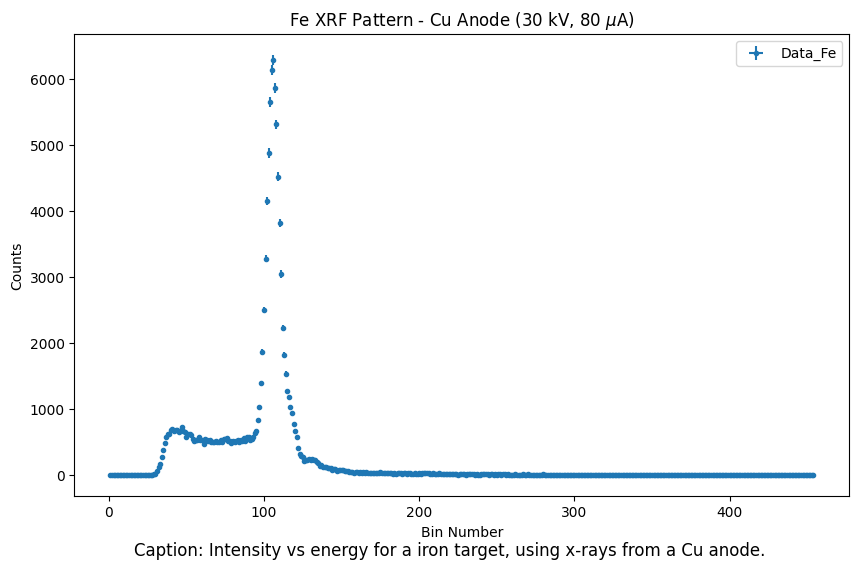

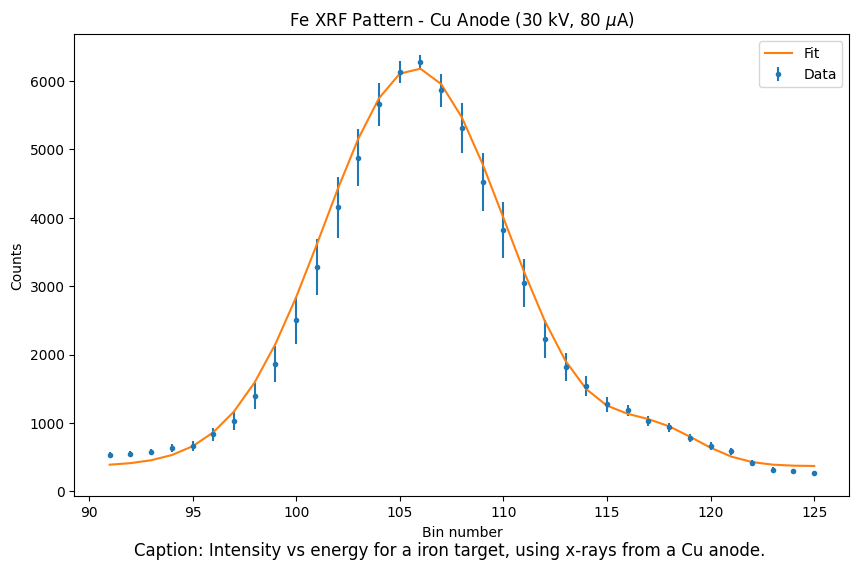

In [44]:
#KEY REMOVE FOR STUDENTS
#Import "Elements.txt"
data = genfromtxt("Elements.txt", delimiter='	', skip_header=0)
Bin = data[:, 0]
I_Fe = data[:, 8]
Bin_error = np.array([0.5 for x in Bin])
I_Fe_error = np.sqrt(I_Fe)

Bin_range = Bin[90:125]
Bin_error_range = Bin_error[90:125]
I_Fe_range = I_Fe[90:125]
I_Fe_error_range = I_Fe_error[90:125]

#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(Bin, I_Fe, xerr = Bin_error, yerr = I_Fe_error, fmt='.', label="Data_Fe")
plt.legend()
plt.xlabel('Bin Number')
plt.ylabel('Counts')
plt.title(r'Fe XRF Pattern - Cu Anode (30 kV, 80 $\mu$A)')
plt.figtext(0.5, 0.01, "Caption: Intensity vs energy for a iron target, using x-rays from a Cu anode.", wrap=True, horizontalalignment='center', fontsize=12)

#Make a Model Function
def Gaussian_Fe(x, a1, mu1, sigma1, a2, mu2, sigma2, y0):
    g = a1 * np.exp(-0.5 * (x - mu1)**2 / sigma1**2) + a2 * np.exp(-0.5 * (x - mu2)**2 / sigma2**2) + y0
    return g

#Preliminarily Fit the Data
guess_a1 = 7000
guess_mu1 = 105
guess_sigma1 = 5
guess_a2 = 400
guess_mu2 = 115
guess_sigma2 = 5
guess_y0 = 1



guess=np.array([guess_a1, guess_mu1, guess_sigma1, guess_a2, guess_mu2, guess_sigma2, guess_y0])

uw_fits,uw_covs=curve_fit(Gaussian_Fe, Bin_range, I_Fe_range, p0=guess)
uw_sig=np.sqrt(np.diag(uw_covs))

#Calculate dg/dx
a1, mu1, sigma1, a2, mu2, sigma2, y0 = uw_fits
dg_dx = -((Bin_range - mu1) / sigma1**2) * a1 * np.exp(-0.5 * (Bin_range - mu1)**2 / sigma1**2) - ((Bin_range - mu2) / sigma2**2) * a2 * np.exp(-0.5 * (Bin_range - mu2)**2 / sigma2**2)
#Calculate total error
sigmas= np.sqrt(I_Fe_error_range**2 + (dg_dx * Bin_error_range)**2)

#Perform weighted fit
fits, covs=curve_fit(Gaussian_Fe, Bin_range, I_Fe_range, p0=guess, sigma=sigmas)
stds=np.sqrt(np.diag(covs))


#Calculate reduced chi squared
Red_chi_sq_Fe= 1.0/(Bin_range.size-7.0) * np.sum((I_Fe_range - Gaussian_Fe(Bin_range, *fits))**2/sigmas**2)
print(f'Reduced Chi Squared = {Red_chi_sq_Fe:.3f}')
print(f"a1 = {fits[0]:.3f} ± {stds[0]:.3f}")
print(f"mu1 = {fits[1]:.3f} ± {stds[1]:.3f}")
print(f"sigma1 = {fits[2]:.3f} ± {stds[2]:.3f}")
print(f"a2 = {fits[3]:.3f} ± {stds[3]:.3f}")
print(f"mu2 = {fits[4]:.3f} ± {stds[4]:.3f}")
print(f"sigma2 = {fits[5]:.3f} ± {stds[5]:.3f}")
print(f"y0 = {fits[6]:.3f} ± {stds[6]:.3f}")
                 

#Plot the fit with the data!
fit_I_Fe = Gaussian_Fe(Bin_range, *fits)
fig1=plt.figure(1, figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(Bin_range, I_Fe_range, yerr=sigmas, fmt='.', label="Data")
plt.plot(Bin_range, fit_I_Fe, '-', label="Fit")
plt.legend()
plt.xlabel('Bin number')
plt.ylabel('Counts')
plt.title(r'Fe XRF Pattern - Cu Anode (30 kV, 80 $\mu$A)')
plt.figtext(0.5, 0.01, "Caption: Intensity vs energy for a iron target, using x-rays from a Cu anode.", wrap=True, horizontalalignment='center', fontsize=12)





## Moseley's Plot

Reduced Chi Squared = 0.005
m = 9.932 ± 0.059
b = 0.812 ± 0.156
Reduced Chi Squared = 0.002
m = 9.538 ± 0.032
b = 0.519 ± 0.090


Text(0.5, 0.01, 'Caption:, plotted')

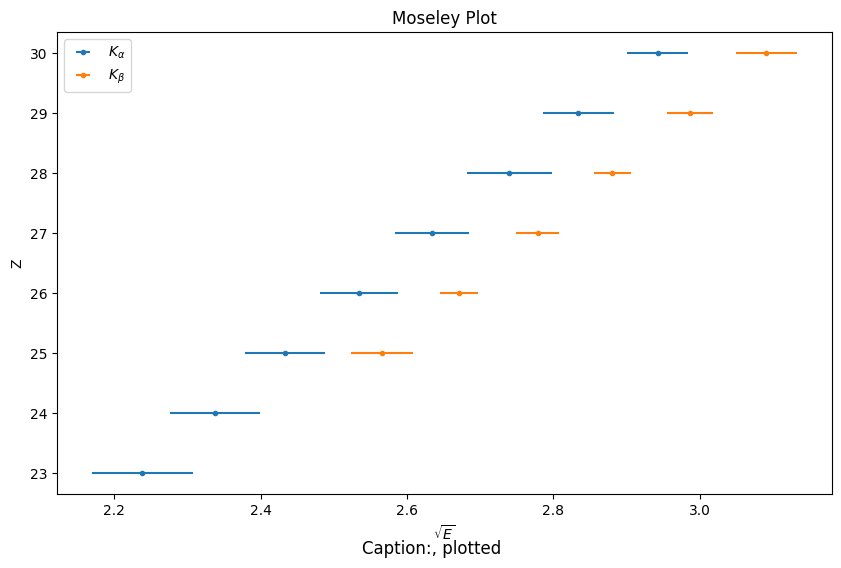

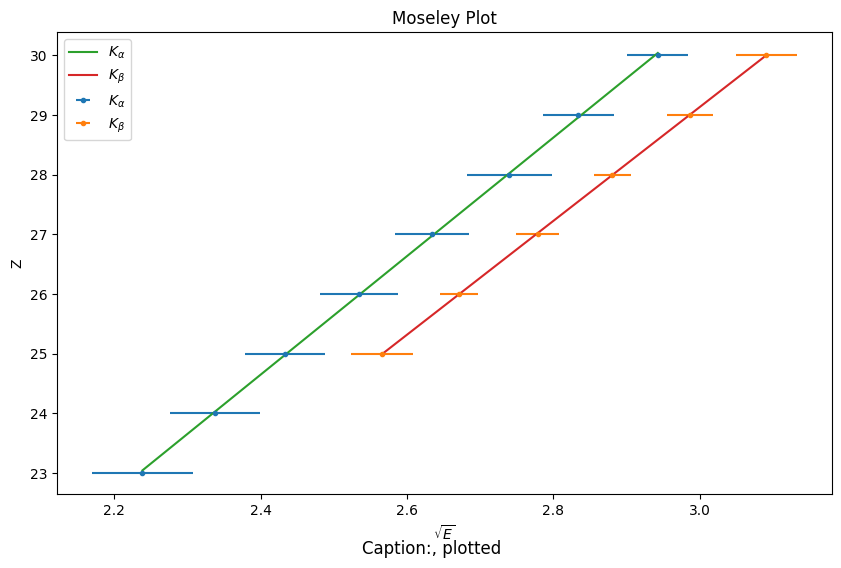

In [4]:
#KEY REMOVE FOR STUDENTS
#Import "MoseleyPlot.txt"
data = genfromtxt("MoseleyPlot.txt", delimiter=None, skip_header=0)
Z = data[:, 0]
Bin_K_alpha = data[:, 1]
Bin_K_alpha_error = data[:, 2]
Bin_K_beta = data[:, 3]
Bin_K_beta_error = data[:, 4]

m_cal = 0.061 
b_cal = -0.029 
m_error_cal = 0.0001235090778537165
b_error_cal = 0.026433248531027364
E_K_alpha = m_cal * Bin_K_alpha + b_cal
E_K_beta = m_cal * Bin_K_beta + b_cal

mask = Bin_K_beta > 0
Z_beta_filtered = Z[mask]
E_K_beta_filtered = E_K_beta[mask]

E_K_alpha_error = np.sqrt((Bin_K_alpha * m_error_cal)**2 + b_error_cal**2 + (m_cal * Bin_K_alpha_error)**2)
E_K_beta_error = np.sqrt((Bin_K_beta * m_error_cal)**2 + b_error_cal**2 + (m_cal * Bin_K_beta_error)**2)
E_K_beta_error_filtered = E_K_beta_error[mask]
sqrt_E_K_alpha_error = (1 / (2 * np.sqrt(E_K_alpha))) * E_K_alpha_error
sqrt_E_K_beta_error = (1 / (2 * np.sqrt(E_K_beta_filtered))) * E_K_beta_error_filtered

#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(np.sqrt(E_K_alpha), Z, xerr = sqrt_E_K_alpha_error, fmt='.', label=r"$K_\alpha$")
plt.errorbar(np.sqrt(E_K_beta_filtered), Z_beta_filtered, xerr = sqrt_E_K_beta_error, fmt='.', label=r"$K_\beta$")
plt.legend()
plt.xlabel(r'$\sqrt{E}$')
plt.ylabel('Z')
plt.title("Moseley Plot")
plt.figtext(0.5, 0.01, "Caption:, plotted", wrap=True, horizontalalignment='center', fontsize=12)

#Make a Model Function
def Moseleys_Law(x, m, b):
    y = m * x + b
    return y

#Preliminarily Fit the Data
guess_m = 9.90
guess_b = 1



guess=np.array([guess_m, guess_b])

uw_fits_K_alpha, uw_covs_alpha = curve_fit(Moseleys_Law, np.sqrt(E_K_alpha), Z, p0=guess)
uw_sig_alpha=np.sqrt(np.diag(uw_covs_alpha))
approx_slope_K_alpha = uw_fits_K_alpha[0]

uw_fits_K_beta, uw_covs_beta = curve_fit(Moseleys_Law, np.sqrt(E_K_beta_filtered), Z_beta_filtered, p0=guess)
uw_sig_beta=np.sqrt(np.diag(uw_covs_beta))
approx_slope_K_beta = uw_fits_K_beta[0]


#Calculate total error
sigmas_alpha = approx_slope_K_alpha * sqrt_E_K_alpha_error
sigmas_beta = approx_slope_K_beta * sqrt_E_K_beta_error

#Perform weighted fit
fits_alpha, covs_alpha=curve_fit(Moseleys_Law, np.sqrt(E_K_alpha), Z, p0=guess, sigma=sigmas_alpha)
stds_alpha = np.sqrt(np.diag(covs_alpha))

fits_beta, covs_beta = curve_fit(Moseleys_Law, np.sqrt(E_K_beta_filtered), Z_beta_filtered, p0=guess, sigma = sigmas_beta)
stds_beta = np.sqrt(np.diag(covs_beta))

#Calculate reduced chi squared
Red_chi_sq_alpha= 1.0/(Z.size-2.0) * np.sum((Z - Moseleys_Law(np.sqrt(E_K_alpha), *fits_alpha))**2/sigmas_alpha**2)
print(f'Reduced Chi Squared = {Red_chi_sq_alpha:.3f}')
print(f"m = {fits_alpha[0]:.3f} ± {stds_alpha[0]:.3f}")
print(f"b = {fits_alpha[1]:.3f} ± {stds_alpha[1]:.3f}")
Red_chi_sq_beta = 1.0 / (Z_beta_filtered.size - 2.0) * np.sum((Z_beta_filtered - Moseleys_Law(np.sqrt(E_K_beta_filtered), *fits_beta))**2 / sigmas_beta**2)
print(f'Reduced Chi Squared = {Red_chi_sq_beta:.3f}')
print(f"m = {fits_beta[0]:.3f} ± {stds_beta[0]:.3f}")
print(f"b = {fits_beta[1]:.3f} ± {stds_beta[1]:.3f}")
                 

#Plot the fit with the data!
fit_Z_alpha = Moseleys_Law(np.sqrt(E_K_alpha), *fits_alpha)
fit_Z_beta = Moseleys_Law(np.sqrt(E_K_beta_filtered), *fits_beta)
fig1=plt.figure(1, figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(np.sqrt(E_K_alpha), Z, xerr=sqrt_E_K_alpha_error, fmt='.', label=r"$K_\alpha$")
plt.errorbar(np.sqrt(E_K_beta_filtered), Z_beta_filtered, xerr = sqrt_E_K_beta_error, fmt = '.', label = r"$K_\beta$")
plt.plot(np.sqrt(E_K_alpha), fit_Z_alpha, '-', label=r"$K_\alpha$")
plt.plot(np.sqrt(E_K_beta_filtered), fit_Z_beta, '-', label = r"$K_\beta$")
plt.legend()
plt.xlabel(r'$\sqrt{E}$')
plt.ylabel('Z')
plt.title("Moseley Plot")
plt.figtext(0.5, 0.01, "Caption:, plotted", wrap=True, horizontalalignment='center', fontsize=12)






## Moseley's Law: Part 2  
Stainless steel, regular steel, brass, unknown

### Unknown Metal 1

Reduced Chi Squared = 2.235
a1 = 942.642 ± 40.384
mu1 = 89.767 ± 0.219
sigma1 = 3.266 ± 0.190
a2 = 2734.393 ± 69.805
mu2 = 105.650 ± 0.167
sigma2 = 4.236 ± 0.116
y0 = 457.044 ± 18.431


Text(0.5, 0.01, 'Caption: Intensity vs energy for an unknown metal target, using x-rays from a Cu anode.')

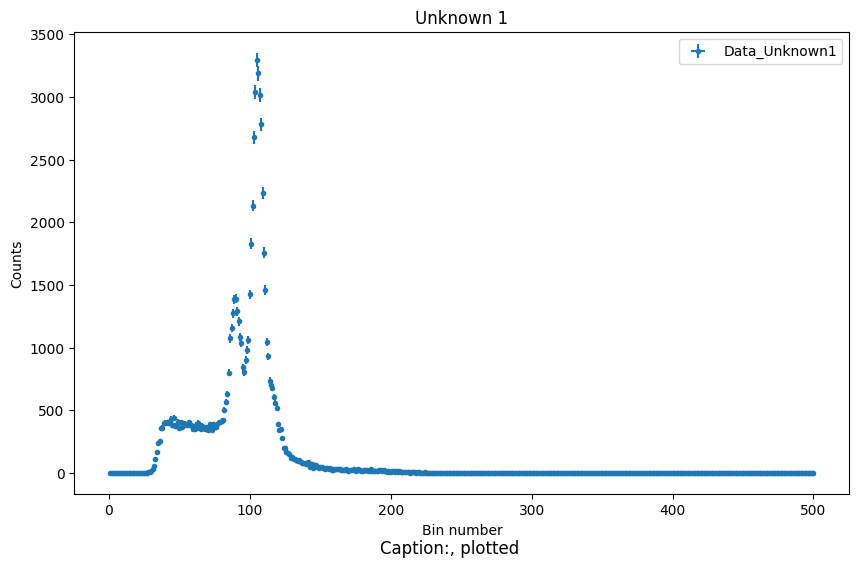

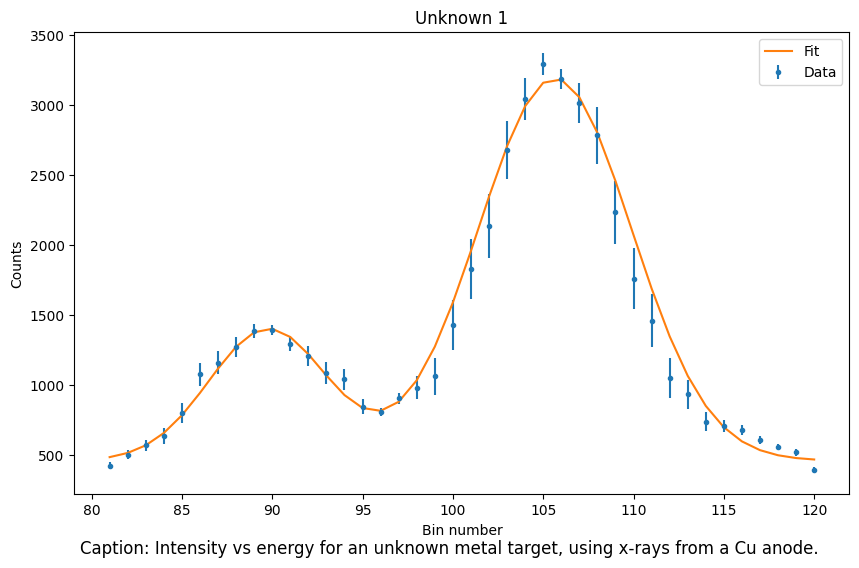

In [46]:
#KEY REMOVE FOR STUDENTS
#Import "UnknownMetals.txt"
data = genfromtxt("UnknownMetals.txt", delimiter='	', skip_header=0)
Bin = data[:, 0]
I_Unknown1 = data[:, 1]
Bin_error = np.array([0.5 for x in Bin])
I_Unknown1_error = np.sqrt(I_Unknown1)

Bin_range = Bin[80:120]
Bin_error_range = Bin_error[80:120]
I_Unknown1_range = I_Unknown1[80:120]
I_Unknown1_error_range = I_Unknown1_error[80:120]

#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(Bin, I_Unknown1, xerr = Bin_error, yerr = I_Unknown1_error, fmt='.', label="Data_Unknown1")
plt.legend()
plt.xlabel('Bin number')
plt.ylabel('Counts')
plt.title('Unknown 1')
plt.figtext(0.5, 0.01, "Caption:, plotted", wrap=True, horizontalalignment='center', fontsize=12)

#Make a Model Function
def Gaussian_Unknown1(x, a1, mu1, sigma1, a2, mu2, sigma2, y0):
    g = a1 * np.exp(-0.5 * (x - mu1)**2 / sigma1**2) + a2 * np.exp(-0.5 * (x - mu2)**2 / sigma2**2) + y0
    return g

#Preliminarily Fit the Data
guess_a1 = 1500
guess_mu1 = 90
guess_sigma1 = 5
guess_a2 = 3400
guess_mu2 = 110
guess_sigma2 = 5
guess_y0 = 1



guess=np.array([guess_a1, guess_mu1, guess_sigma1, guess_a2, guess_mu2, guess_sigma2, guess_y0])

uw_fits,uw_covs=curve_fit(Gaussian_Unknown1, Bin_range, I_Unknown1_range, p0=guess)
uw_sig=np.sqrt(np.diag(uw_covs))

#Calculate dg/dx
a1, mu1, sigma1, a2, mu2, sigma2, y0 = uw_fits
dg_dx = -((Bin_range - mu1) / sigma1**2) * a1 * np.exp(-0.5 * (Bin_range - mu1)**2 / sigma1**2) - ((Bin_range - mu2) / sigma2**2) * a2 * np.exp(-0.5 * (Bin_range - mu2)**2 / sigma2**2)
#Calculate total error
sigmas= np.sqrt(I_Unknown1_error_range**2 + (dg_dx * Bin_error_range)**2)

#Perform weighted fit
fits, covs=curve_fit(Gaussian_Unknown1, Bin_range, I_Unknown1_range, p0=guess, sigma=sigmas)
stds=np.sqrt(np.diag(covs))


#Calculate reduced chi squared
Red_chi_sq_swing= 1.0/(Bin_range.size-7.0) * np.sum((I_Unknown1_range - Gaussian_Unknown1(Bin_range, *fits))**2/sigmas**2)
print(f'Reduced Chi Squared = {Red_chi_sq_swing:.3f}')
print(f"a1 = {fits[0]:.3f} ± {stds[0]:.3f}")
print(f"mu1 = {fits[1]:.3f} ± {stds[1]:.3f}")
print(f"sigma1 = {fits[2]:.3f} ± {stds[2]:.3f}")
print(f"a2 = {fits[3]:.3f} ± {stds[3]:.3f}")
print(f"mu2 = {fits[4]:.3f} ± {stds[4]:.3f}")
print(f"sigma2 = {fits[5]:.3f} ± {stds[5]:.3f}")
print(f"y0 = {fits[6]:.3f} ± {stds[6]:.3f}")
                 

#Plot the fit with the data!
fit_I_Unknown1 = Gaussian_Unknown1(Bin_range, *fits)
fig1=plt.figure(1, figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(Bin_range, I_Unknown1_range, yerr=sigmas, fmt='.', label="Data")
plt.plot(Bin_range, fit_I_Unknown1, '-', label="Fit")
plt.legend()
plt.xlabel('Bin number')
plt.ylabel('Counts')
plt.title('Unknown 1')
plt.figtext(0.5, 0.01, "Caption: Intensity vs energy for an unknown metal target, using x-rays from a Cu anode.", wrap=True, horizontalalignment='center', fontsize=12)





The characteristic peaks were found at $\mu_1 = 89.767 ± 0.219$ and $\mu_2 = 105.650 ± 0.167$. These correspond to chromium and iron respectively. Unknown metal 1 is therefore stainless steel which is an alloy made from those two metals.

### Unknown Metal 2

Reduced Chi Squared = 1.961
a1 = 3400.089 ± 101.938
mu1 = 106.069 ± 0.157
sigma1 = 3.950 ± 0.225
y0 = 398.988 ± 87.283


Text(0.5, 0.01, 'Caption: Intensity vs energy for an unknown metal target, using x-rays from a Cu anode.')

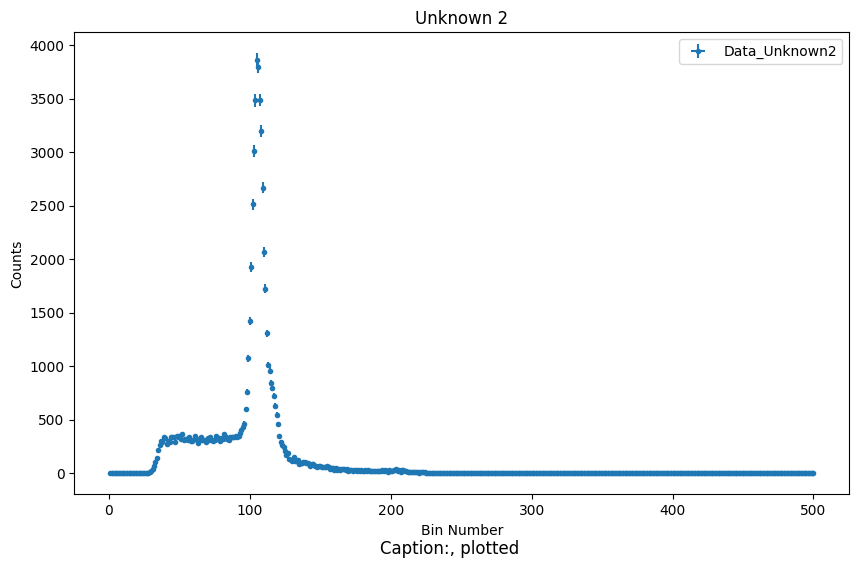

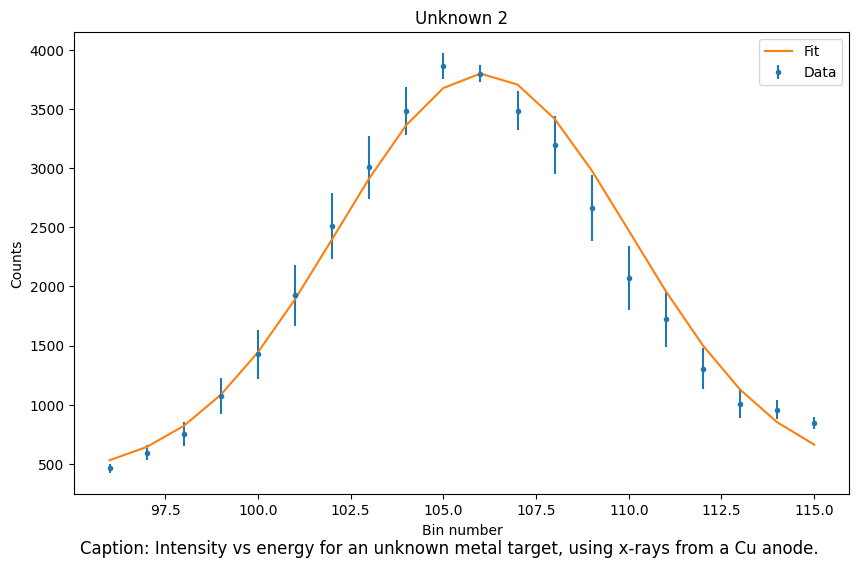

In [3]:
#KEY REMOVE FOR STUDENTS
#Import "UnknownMetals.txt"
data = genfromtxt("UnknownMetals.txt", delimiter='	', skip_header=0)
Bin = data[:, 0]
I_Unknown2 = data[:, 2]
Bin_error = np.array([0.5 for x in Bin])
I_Unknown2_error = np.sqrt(I_Unknown2)

Bin_range = Bin[95:115]
Bin_error_range = Bin_error[95:115]
I_Unknown2_range = I_Unknown2[95:115]
I_Unknown2_error_range = I_Unknown2_error[95:115]

#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(Bin, I_Unknown2, xerr = Bin_error, yerr = I_Unknown2_error, fmt='.', label="Data_Unknown2")
plt.legend()
plt.xlabel('Bin Number')
plt.ylabel('Counts')
plt.title('Unknown 2')
plt.figtext(0.5, 0.01, "Caption:, plotted", wrap=True, horizontalalignment='center', fontsize=12)

#Make a Model Function
def Gaussian_Unknown2(x, a1, mu1, sigma1, y0):
    g = a1 * np.exp(-0.5 * (x - mu1)**2 / sigma1**2) + y0
    return g

#Preliminarily Fit the Data
guess_a1 = 4000
guess_mu1 = 105
guess_sigma1 = 5
guess_y0 = 1



guess=np.array([guess_a1, guess_mu1, guess_sigma1, guess_y0])

uw_fits,uw_covs=curve_fit(Gaussian_Unknown2, Bin_range, I_Unknown2_range, p0=guess)
uw_sig=np.sqrt(np.diag(uw_covs))

#Calculate dg/dx
a1, mu1, sigma1, y0 = uw_fits
dg_dx = -((Bin_range - mu1) / sigma1**2) * a1 * np.exp(-0.5 * (Bin_range - mu1)**2 / sigma1**2)
#Calculate total error
sigmas= np.sqrt(I_Unknown2_error_range**2 + (dg_dx * Bin_error_range)**2)

#Perform weighted fit
fits, covs=curve_fit(Gaussian_Unknown2, Bin_range, I_Unknown2_range, p0=guess, sigma=sigmas)
stds=np.sqrt(np.diag(covs))


#Calculate reduced chi squared
Red_chi_sq_swing= 1.0/(Bin_range.size-4.0) * np.sum((I_Unknown2_range - Gaussian_Unknown2(Bin_range, *fits))**2/sigmas**2)
print(f'Reduced Chi Squared = {Red_chi_sq_swing:.3f}')
print(f"a1 = {fits[0]:.3f} ± {stds[0]:.3f}")
print(f"mu1 = {fits[1]:.3f} ± {stds[1]:.3f}")
print(f"sigma1 = {fits[2]:.3f} ± {stds[2]:.3f}")
print(f"y0 = {fits[3]:.3f} ± {stds[3]:.3f}")
                 


#Plot the fit with the data!
fit_I_Unknown2 = Gaussian_Unknown2(Bin_range, *fits)
fig1=plt.figure(1, figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(Bin_range, I_Unknown2_range, yerr=sigmas, fmt='.', label="Data")
plt.plot(Bin_range, fit_I_Unknown2, '-', label="Fit")
plt.legend()
plt.xlabel('Bin number')
plt.ylabel('Counts')
plt.title('Unknown 2')
plt.figtext(0.5, 0.01, "Caption: Intensity vs energy for an unknown metal target, using x-rays from a Cu anode.", wrap=True, horizontalalignment='center', fontsize=12)





The characteristic peaks were found at $\mu_1 = 105.501 ± 0.089$ and $\mu_2 = 116.234 ± 0.283$. These correspond to $K_\alpha$ and $K_\beta$ for iron respectively. Unknown metal 2 is therefore rusted metal.

### Unknown Metal 3

Reduced Chi Squared = 1.658
a1 = 3279.366 ± 59.088
mu1 = 132.338 ± 0.245
sigma1 = 4.629 ± 0.143
a2 = 1354.843 ± 59.151
mu2 = 143.682 ± 0.353
sigma2 = 3.732 ± 0.240
y0 = 141.315 ± 15.662


Text(0.5, 0.01, 'Caption: Intensity vs energy for an unknown metal target, using x-rays from a Cu anode.')

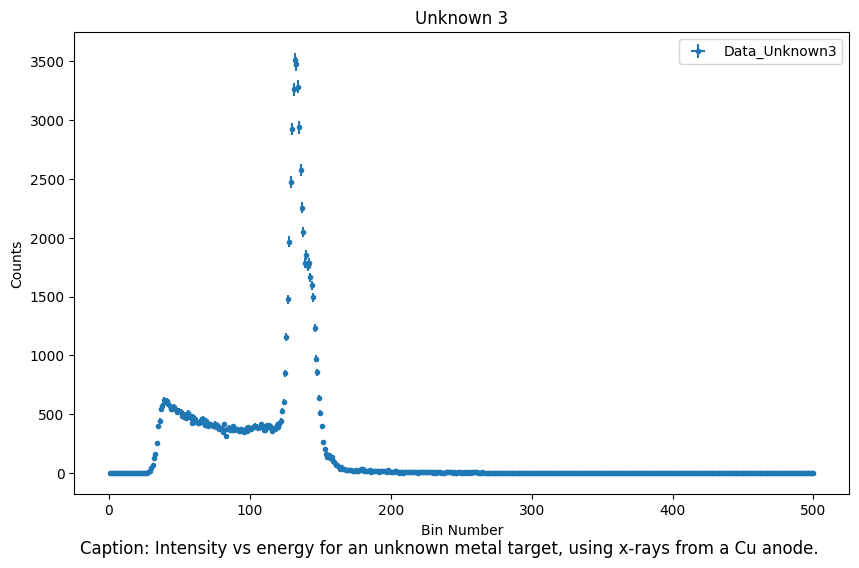

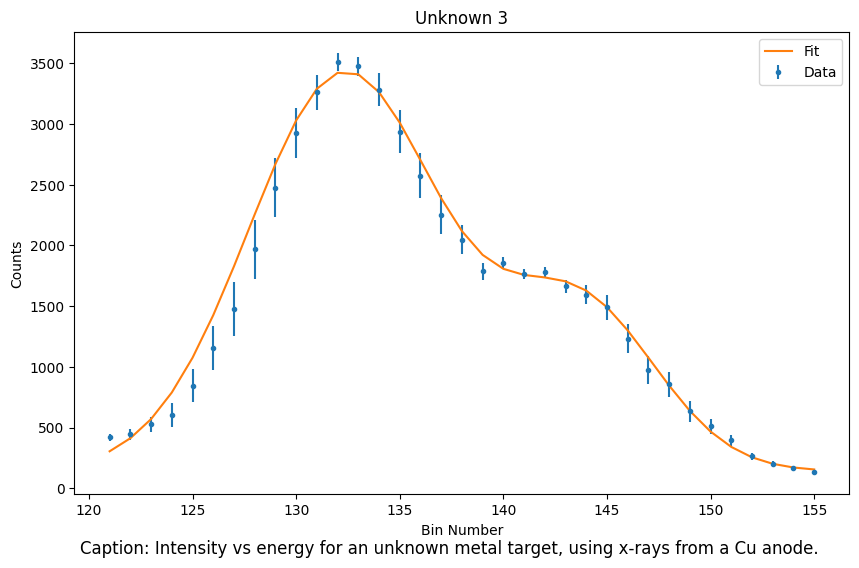

In [12]:
#KEY REMOVE FOR STUDENTS
#Import "UnknownMetals.txt"
data = genfromtxt("UnknownMetals.txt", delimiter='	', skip_header=0)
Bin = data[:, 0]
I_Unknown3 = data[:, 3]
Bin_error = np.array([0.5 for x in Bin])
I_Unknown3_error = np.sqrt(I_Unknown3)

Bin_range = Bin[120:155]
Bin_error_range = Bin_error[120:155]
I_Unknown3_range = I_Unknown3[120:155]
I_Unknown3_error_range = I_Unknown3_error[120:155]

#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(Bin, I_Unknown3, xerr = Bin_error, yerr = I_Unknown3_error, fmt='.', label="Data_Unknown3")
plt.legend()
plt.xlabel('Bin Number')
plt.ylabel('Counts')
plt.title('Unknown 3')
plt.figtext(0.5, 0.01, "Caption: Intensity vs energy for an unknown metal target, using x-rays from a Cu anode.", wrap=True, horizontalalignment='center', fontsize=12)

#Make a Model Function
def Gaussian_Unknown3(x, a1, mu1, sigma1, a2, mu2, sigma2, y0):
    g = a1 * np.exp(-0.5 * (x - mu1)**2 / sigma1**2) + a2 * np.exp(-0.5 * (x - mu2)**2 / sigma2**2) + y0
    return g

#Preliminarily Fit the Data
guess_a1 = 5000
guess_mu1 = 130
guess_sigma1 = 5
guess_a2 = 1800
guess_mu2 = 140
guess_sigma2 = 5
guess_y0 = 1



guess=np.array([guess_a1, guess_mu1, guess_sigma1, guess_a2, guess_mu2, guess_sigma2, guess_y0])

uw_fits,uw_covs=curve_fit(Gaussian_Unknown3, Bin_range, I_Unknown3_range, p0=guess)
uw_sig=np.sqrt(np.diag(uw_covs))

#Calculate dg/dx
a1, mu1, sigma1, a2, mu2, sigma2, y0 = uw_fits
dg_dx = -((Bin_range - mu1) / sigma1**2) * a1 * np.exp(-0.5 * (Bin_range - mu1)**2 / sigma1**2) - ((Bin_range - mu2) / sigma2**2) * a2 * np.exp(-0.5 * (Bin_range - mu2)**2 / sigma2**2)
#Calculate total error
sigmas= np.sqrt(I_Unknown3_error_range**2 + (dg_dx * Bin_error_range)**2)

#Perform weighted fit
fits, covs=curve_fit(Gaussian_Unknown3, Bin_range, I_Unknown3_range, p0=guess, sigma=sigmas)
stds=np.sqrt(np.diag(covs))


#Calculate reduced chi squared
Red_chi_sq_Unknown3= 1.0/(Bin_range.size-7.0) * np.sum((I_Unknown3_range - Gaussian_Unknown3(Bin_range, *fits))**2/sigmas**2)
print(f'Reduced Chi Squared = {Red_chi_sq_Unknown3:.3f}')
print(f"a1 = {fits[0]:.3f} ± {stds[0]:.3f}")
print(f"mu1 = {fits[1]:.3f} ± {stds[1]:.3f}")
print(f"sigma1 = {fits[2]:.3f} ± {stds[2]:.3f}")
print(f"a2 = {fits[3]:.3f} ± {stds[3]:.3f}")
print(f"mu2 = {fits[4]:.3f} ± {stds[4]:.3f}")
print(f"sigma2 = {fits[5]:.3f} ± {stds[5]:.3f}")
print(f"y0 = {fits[6]:.3f} ± {stds[6]:.3f}")
                 

#Plot the fit with the data!
fit_I_Unknown3 = Gaussian_Unknown3(Bin_range, *fits)
fig1=plt.figure(1, figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(Bin_range, I_Unknown3_range, yerr=sigmas, fmt='.', label="Data")
plt.plot(Bin_range, fit_I_Unknown3, '-', label="Fit")
plt.legend()
plt.xlabel('Bin Number')
plt.ylabel('Counts')
plt.title('Unknown 3')
plt.figtext(0.5, 0.01, "Caption: Intensity vs energy for an unknown metal target, using x-rays from a Cu anode.", wrap=True, horizontalalignment='center', fontsize=12)





The characteristic peaks were found at $\mu_1 = 132.338 ± 0.245$ and $\mu_2 = 143.682 ± 0.353$. These correspond to copper and zinc respectively. Unknown metal 3 is therefore brass which is an alloy made from those two metals.

### Unknown Metal 4

Reduced Chi Squared = 0.899
a1 = 731.413 ± 10.797
mu1 = 104.333 ± 0.281
sigma1 = 11.020 ± 0.435
a2 = 3361.881 ± 69.275
mu2 = 122.939 ± 0.179
sigma2 = 3.660 ± 0.126
a3 = 1370.067 ± 39.517
mu3 = 132.969 ± 0.398
sigma3 = 4.438 ± 0.225
y0 = 123.226 ± 5.636


Text(0.5, 0.01, 'Caption: Intensity vs energy for an unknown metal target, using x-rays from a Cu anode.')

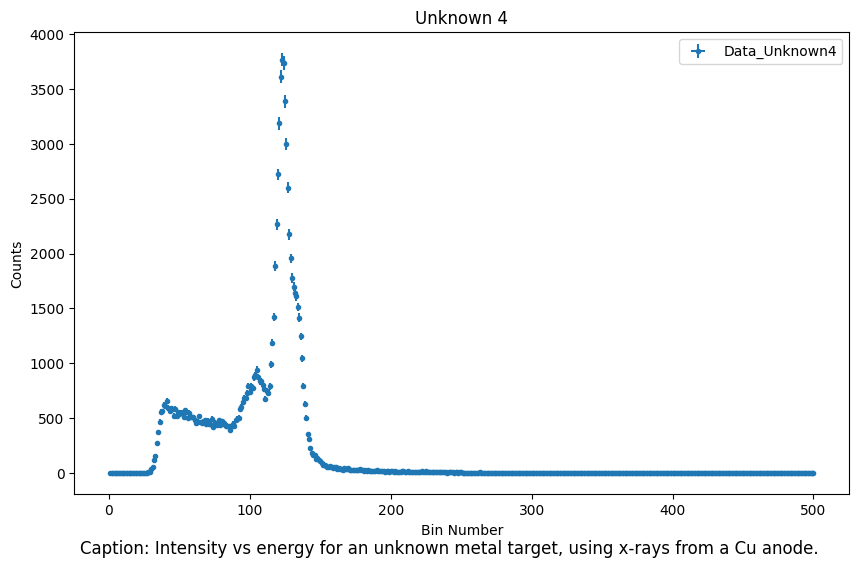

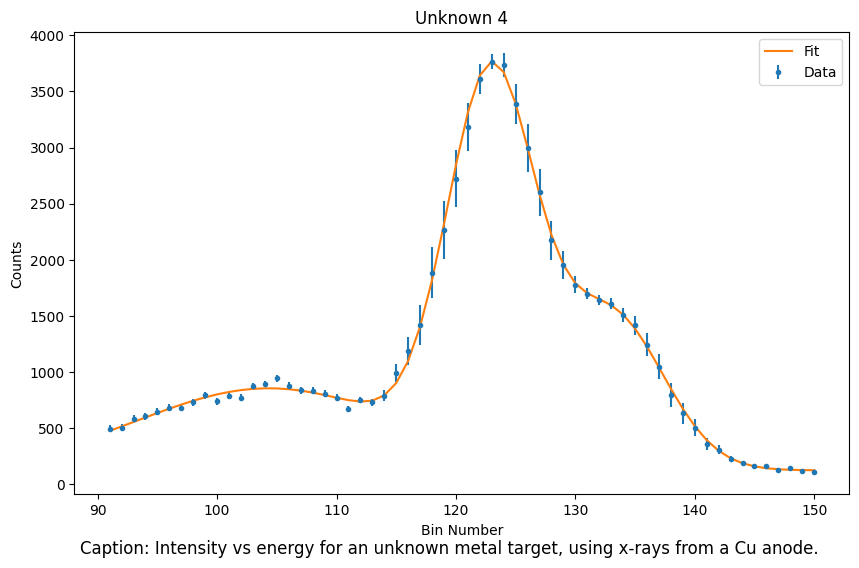

In [13]:
#KEY REMOVE FOR STUDENTS
#Import "UnknownMetals.txt"
data = genfromtxt("UnknownMetals.txt", delimiter='	', skip_header=0)
Bin = data[:, 0]
I_Unknown4 = data[:, 4]
Bin_error = np.array([0.5 for x in Bin])
I_Unknown4_error = np.sqrt(I_Unknown4)

Bin_range = Bin[90:150]
Bin_error_range = Bin_error[90:150]
I_Unknown4_range = I_Unknown4[90:150]
I_Unknown4_error_range = I_Unknown4_error[90:150]

#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(Bin, I_Unknown4, xerr = Bin_error, yerr = I_Unknown4_error, fmt='.', label="Data_Unknown4")
plt.legend()
plt.xlabel('Bin Number')
plt.ylabel('Counts')
plt.title('Unknown 4')
plt.figtext(0.5, 0.01, "Caption: Intensity vs energy for an unknown metal target, using x-rays from a Cu anode.", wrap=True, horizontalalignment='center', fontsize=12)

#Make a Model Function
def Gaussian_Unknown4(x, a1, mu1, sigma1, a2, mu2, sigma2, a3, mu3, sigma3, y0):
    g = a1 * np.exp(-0.5 * (x - mu1)**2 / sigma1**2) + a2 * np.exp(-0.5 * (x - mu2)**2 / sigma2**2) + a3 * np.exp(-0.5 * (x - mu3)**2 / sigma3**2) + y0
    return g

#Preliminarily Fit the Data
guess_a1 = 1000
guess_mu1 = 105
guess_sigma1 = 5
guess_a2 = 3800
guess_mu2 = 120
guess_sigma2 = 5
guess_a3 = 1700
guess_mu3 = 132
guess_sigma3 = 5
guess_y0 = 1



guess=np.array([guess_a1, guess_mu1, guess_sigma1, guess_a2, guess_mu2, guess_sigma2, guess_a3, guess_mu3, guess_sigma3, guess_y0])

uw_fits,uw_covs=curve_fit(Gaussian_Unknown4, Bin_range, I_Unknown4_range, p0=guess)
uw_sig=np.sqrt(np.diag(uw_covs))

#Calculate dg/dx
a1, mu1, sigma1, a2, mu2, sigma2, a3, mu3, sigma3, y0 = uw_fits
dg_dx = -((Bin_range - mu1) / sigma1**2) * a1 * np.exp(-0.5 * (Bin_range - mu1)**2 / sigma1**2) - ((Bin_range - mu2) / sigma2**2) * a2 * np.exp(-0.5 * (Bin_range - mu2)**2 / sigma2**2) - ((Bin_range - mu3) / sigma3**2) * a3 * np.exp(-0.5 * (Bin_range - mu3)**2 / sigma3**2)
#Calculate total error
sigmas= np.sqrt(I_Unknown4_error_range**2 + (dg_dx * Bin_error_range)**2)

#Perform weighted fit
fits, covs=curve_fit(Gaussian_Unknown4, Bin_range, I_Unknown4_range, p0=guess, sigma=sigmas)
stds=np.sqrt(np.diag(covs))


#Calculate reduced chi squared
Red_chi_sq_Unknown4= 1.0/(Bin_range.size-10.0) * np.sum((I_Unknown4_range - Gaussian_Unknown4(Bin_range, *fits))**2/sigmas**2)
print(f'Reduced Chi Squared = {Red_chi_sq_Unknown4:.3f}')
print(f"a1 = {fits[0]:.3f} ± {stds[0]:.3f}")
print(f"mu1 = {fits[1]:.3f} ± {stds[1]:.3f}")
print(f"sigma1 = {fits[2]:.3f} ± {stds[2]:.3f}")
print(f"a2 = {fits[3]:.3f} ± {stds[3]:.3f}")
print(f"mu2 = {fits[4]:.3f} ± {stds[4]:.3f}")
print(f"sigma2 = {fits[5]:.3f} ± {stds[5]:.3f}")
print(f"a3 = {fits[6]:.3f} ± {stds[6]:.3f}")
print(f"mu3 = {fits[7]:.3f} ± {stds[7]:.3f}")
print(f"sigma3 = {fits[8]:.3f} ± {stds[8]:.3f}")
print(f"y0 = {fits[9]:.3f} ± {stds[9]:.3f}")
                 

#Plot the fit with the data!
fit_I_Unknown4 = Gaussian_Unknown4(Bin_range, *fits)
fig1=plt.figure(1, figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(Bin_range, I_Unknown4_range, yerr=sigmas, fmt='.', label="Data")
plt.plot(Bin_range, fit_I_Unknown4, '-', label="Fit")
plt.legend()
plt.xlabel('Bin Number')
plt.ylabel('Counts')
plt.title('Unknown 4')
plt.figtext(0.5, 0.01, "Caption: Intensity vs energy for an unknown metal target, using x-rays from a Cu anode.", wrap=True, horizontalalignment='center', fontsize=12)





The characteristic peaks were found at $\mu_1 = 104.333 ± 0.281$, $\mu_2 = 122.939 ± 0.179$, and $\mu_3 = 132.969 ± 0.398$. These correspond to iron, nickel, and copper respectively. Unknown metal 4 is therefore cupronickel which is an alloy made from those three metals.

## Bragg's Law

### NaCl

Reduced Chi Squared = 1.054
a1 = 620.498 ± 13.682
mu1 = 28.838 ± 0.010
sigma1 = -0.442 ± 0.013
a2 = 4137.561 ± 50.178
mu2 = 32.038 ± 0.012
sigma2 = 0.432 ± 0.009
y0 = 118.342 ± 7.496


C:\Users\ricky\AppData\Local\Temp\ipykernel_27572\2937758429.py:7: RuntimeWarning: invalid value encountered in sqrt
  cps_error = np.sqrt(cps)


Text(0.5, 0.01, 'Caption: Intensity vs detector angle for a NaCl crystal target, using x-rays from a Cu anode.')

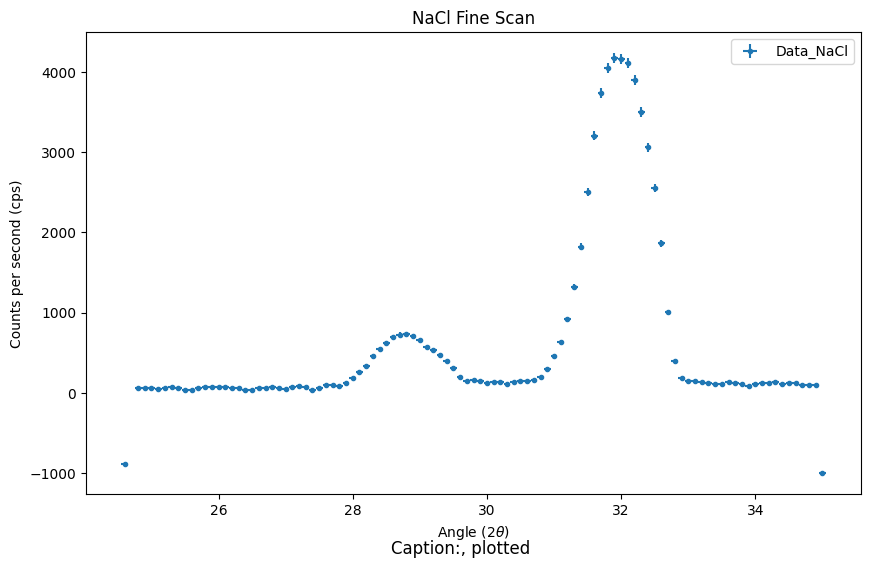

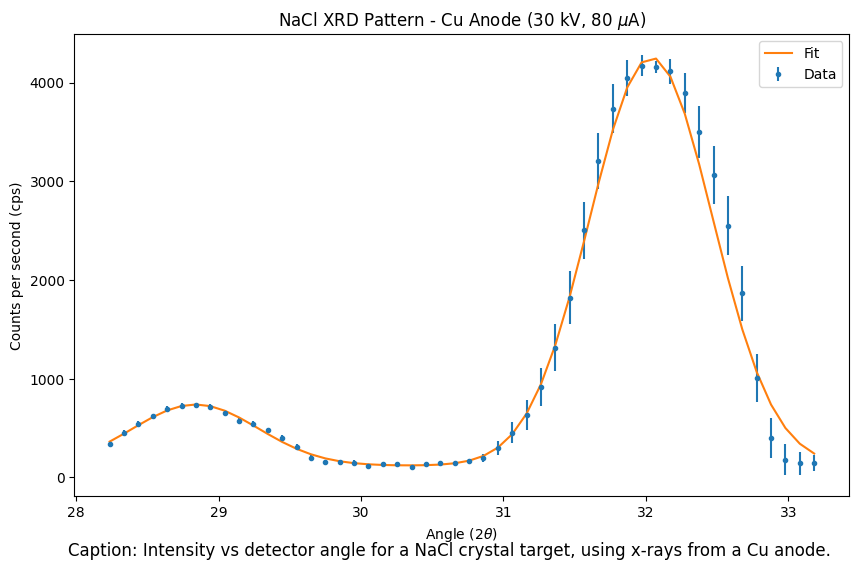

In [5]:
#KEY REMOVE FOR STUDENTS
#Import "NaClFineScan25-35.txt"
data = genfromtxt("NaClFineScan25-35.txt", delimiter='	', skip_header=1)
angle = data[:, 0]
cps = 10 * (data[:, 1] - 100)
angle_error = np.array([0.05 for x in angle])
cps_error = np.sqrt(cps)


m = 10.5 / 10.4
b = (m * -35.0) + 35.1
angle_corrected = m * angle + b

angle_corrected_range = angle_corrected[35:85]
cps_range = cps[35:85]
angle_error_range = angle_error[35:85]
cps_error_range = cps_error[35:85]

#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(angle, cps, xerr = angle_error, yerr = cps_error, fmt='.', label="Data_NaCl")
plt.legend()
plt.xlabel(r'Angle ($2\theta$)')
plt.ylabel('Counts per second (cps)')
plt.title('NaCl Fine Scan')
plt.figtext(0.5, 0.01, "Caption:, plotted", wrap=True, horizontalalignment='center', fontsize=12)

#Make a Model Function
def Gaussian_NaCl(x, a1, mu1, sigma1, a2, mu2, sigma2, y0):
    g = a1 * np.exp(-0.5 * (x - mu1)**2 / sigma1**2) + a2 * np.exp(-0.5 * (x - mu2)**2 / sigma2**2) + y0
    return g

#Preliminarily Fit the Data
guess_a1 = 800
guess_mu1 = 29
guess_sigma1 = 1
guess_a2 = 4100
guess_mu2 = 32
guess_sigma2 = 1
guess_y0 = 1



guess=np.array([guess_a1, guess_mu1, guess_sigma1, guess_a2, guess_mu2, guess_sigma2, guess_y0])

uw_fits,uw_covs=curve_fit(Gaussian_NaCl, angle_corrected_range, cps_range, p0=guess)
uw_sig=np.sqrt(np.diag(uw_covs))

#Calculate dg/dx
a1, mu1, sigma1, a2, mu2, sigma2, y0 = uw_fits
dg_dx = -((angle_corrected_range - mu1) / sigma1**2) * a1 * np.exp(-0.5 * (angle_corrected_range - mu1)**2 / sigma1**2) - ((angle_corrected_range - mu2) / sigma2**2) * a2 * np.exp(-0.5 * (angle_corrected_range - mu2)**2 / sigma2**2)
#Calculate total error
sigmas= np.sqrt(cps_error_range**2 + (dg_dx * angle_error_range)**2)

#Perform weighted fit
fits, covs=curve_fit(Gaussian_NaCl, angle_corrected_range, cps_range, p0=guess, sigma=sigmas)
stds=np.sqrt(np.diag(covs))


#Calculate reduced chi squared
Red_chi_sq_NaCl= 1.0/(angle_corrected_range.size-7.0) * np.sum((cps_range - Gaussian_NaCl(angle_corrected_range, *fits))**2/sigmas**2)
print(f'Reduced Chi Squared = {Red_chi_sq_NaCl:.3f}')
print(f"a1 = {fits[0]:.3f} ± {stds[0]:.3f}")
print(f"mu1 = {fits[1]:.3f} ± {stds[1]:.3f}")
print(f"sigma1 = {fits[2]:.3f} ± {stds[2]:.3f}")
print(f"a2 = {fits[3]:.3f} ± {stds[3]:.3f}")
print(f"mu2 = {fits[4]:.3f} ± {stds[4]:.3f}")
print(f"sigma2 = {fits[5]:.3f} ± {stds[5]:.3f}")
print(f"y0 = {fits[6]:.3f} ± {stds[6]:.3f}")
                 

#Plot the fit with the data!
fit_cps_NaCl = Gaussian_NaCl(angle_corrected_range, *fits)
fig1=plt.figure(1, figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(angle_corrected_range, cps_range, yerr=sigmas, fmt='.', label="Data")
plt.plot(angle_corrected_range, fit_cps_NaCl, '-', label="Fit")
plt.legend()
plt.xlabel(r'Angle ($2\theta$)')
plt.ylabel('Counts per second (cps)')
plt.title(r'NaCl XRD Pattern - Cu Anode (30 kV, 80 $\mu$A)')
plt.figtext(0.5, 0.01, "Caption: Intensity vs detector angle for a NaCl crystal target, using x-rays from a Cu anode.", wrap=True, horizontalalignment='center', fontsize=12)





In [6]:
#Constants
d = 2.820e-10 # meters
n = 1

angle1_radians = fits[1] * (np.pi / 180)
angle1_radians_error = stds[1] * (np.pi / 180)

angle2_radians = fits[4] * (np.pi / 180)
angle2_radians_error = stds[4] * (np.pi / 180)

#Calculate wavelength using Bragg's Law
lambda1 = (2 * d * np.sin(angle1_radians / 2)) / n
lambda1_error = (d / n) * np.cos(angle1_radians / 2) * angle1_radians_error

lambda2 = (2 * d * np.sin(angle2_radians / 2)) / n
lambda2_error = (d / n) * np.cos(angle2_radians / 2) * angle2_radians_error

print(f"Wavelength 1 = {lambda1:.3e} ± {lambda1_error:.3e} meters")
print(f"Wavelength 2 = {lambda2:.3e} ± {lambda2_error:.3e} meters")

# x-ray wavelength = 1.551e-10 m

Wavelength 1 = 1.404e-10 ± 4.697e-14 meters
Wavelength 2 = 1.556e-10 ± 5.808e-14 meters


### LiF

Reduced Chi Squared = 1.836
a1 = 302.756 ± 14.862
mu1 = 40.785 ± 0.023
sigma1 = 0.346 ± 0.021
a2 = 3417.882 ± 56.813
mu2 = 45.556 ± 0.014
sigma2 = 0.458 ± 0.009
y0 = 67.667 ± 2.376


C:\Users\ricky\AppData\Local\Temp\ipykernel_27572\3105141453.py:7: RuntimeWarning: invalid value encountered in sqrt
  cps_error = np.sqrt(cps)


Text(0.5, 0.01, 'Caption: Intensity vs detector angle for a LiF crystal target, using x-rays from a Cu anode.')

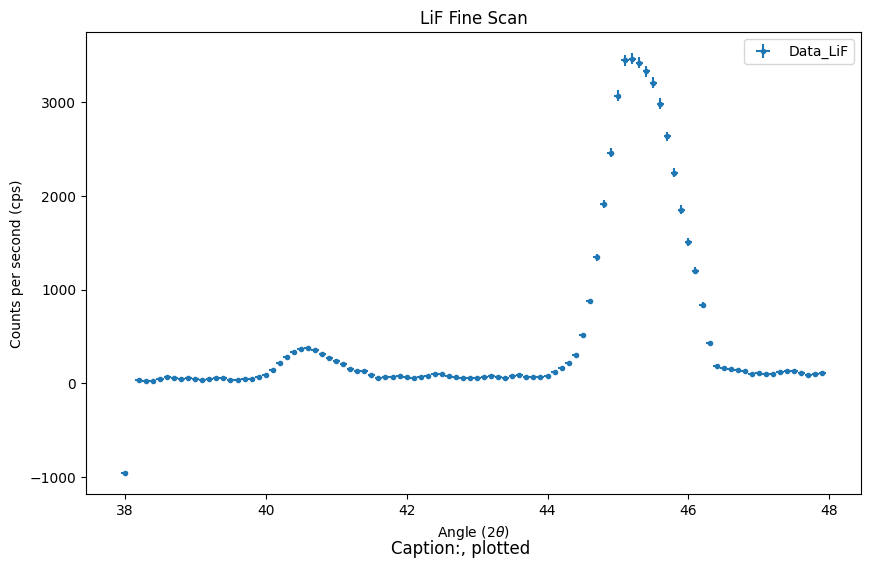

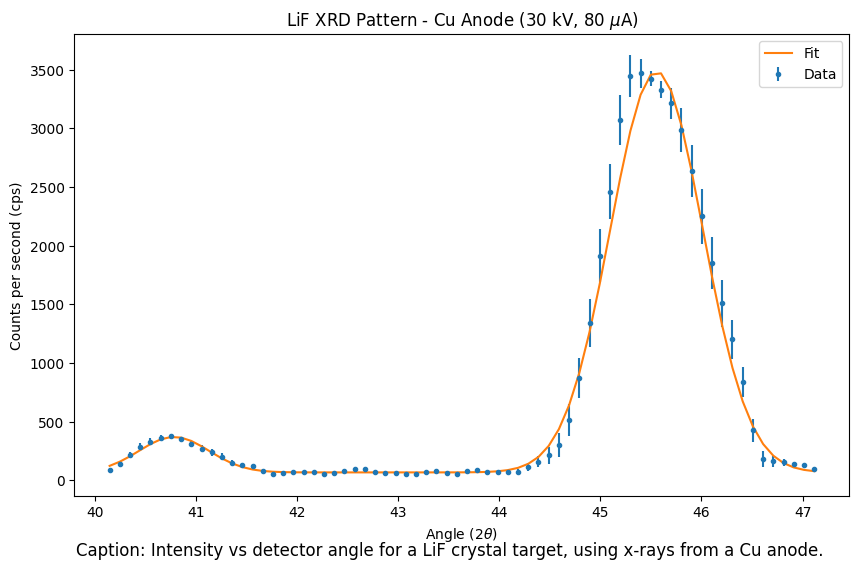

In [7]:
#KEY REMOVE FOR STUDENTS
#Import "LiF_38_48.txt"
data = genfromtxt("LiF_38_48.txt", delimiter='	', skip_header=0)
angle = data[:-1, 0]
cps = 10 * (data[:-1, 1] - 100)
angle_error = np.array([0.05 for x in angle])
cps_error = np.sqrt(cps)

m = 10.5 / 10.4
b = (m * -35.0) + 35.1
angle_corrected = m * angle + b

angle_corrected_range = angle_corrected[20:90]
cps_range = cps[20:90]
angle_error_range = angle_error[20:90]
cps_error_range = cps_error[20:90]

#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(angle, cps, xerr = angle_error, yerr = cps_error, fmt='.', label="Data_LiF")
plt.legend()
plt.xlabel(r'Angle ($2\theta$)')
plt.ylabel('Counts per second (cps)')
plt.title('LiF Fine Scan')
plt.figtext(0.5, 0.01, "Caption:, plotted", wrap=True, horizontalalignment='center', fontsize=12)

#Make a Model Function
def Gaussian_LiF(x, a1, mu1, sigma1, a2, mu2, sigma2, y0):
    g = a1 * np.exp(-0.5 * (x - mu1)**2 / sigma1**2) + a2 * np.exp(-0.5 * (x - mu2)**2 / sigma2**2) + y0
    return g

#Preliminarily Fit the Data
guess_a1 = 400
guess_mu1 = 40.8
guess_sigma1 = 1
guess_a2 = 3500
guess_mu2 = 45.5
guess_sigma2 = 1
guess_y0 = 1



guess=np.array([guess_a1, guess_mu1, guess_sigma1, guess_a2, guess_mu2, guess_sigma2, guess_y0])

uw_fits,uw_covs=curve_fit(Gaussian_LiF, angle_corrected_range, cps_range, p0=guess)
uw_sig=np.sqrt(np.diag(uw_covs))

#Calculate dg/dx
a1, mu1, sigma1, a2, mu2, sigma2, y0 = uw_fits
dg_dx = -((angle_corrected_range - mu1) / sigma1**2) * a1 * np.exp(-0.5 * (angle_corrected_range - mu1)**2 / sigma1**2) - ((angle_corrected_range - mu2) / sigma2**2) * a2 * np.exp(-0.5 * (angle_corrected_range - mu2)**2 / sigma2**2)
#Calculate total error
sigmas= np.sqrt(cps_error_range**2 + (dg_dx * angle_error_range)**2)

#Perform weighted fit
fits, covs=curve_fit(Gaussian_LiF, angle_corrected_range, cps_range, p0=guess, sigma=sigmas)
stds=np.sqrt(np.diag(covs))


#Calculate reduced chi squared
Red_chi_sq_swing= 1.0/(angle_corrected_range.size-7.0) * np.sum((cps_range - Gaussian_LiF(angle_corrected_range, *fits))**2/sigmas**2)
print(f'Reduced Chi Squared = {Red_chi_sq_swing:.3f}')
print(f"a1 = {fits[0]:.3f} ± {stds[0]:.3f}")
print(f"mu1 = {fits[1]:.3f} ± {stds[1]:.3f}")
print(f"sigma1 = {fits[2]:.3f} ± {stds[2]:.3f}")
print(f"a2 = {fits[3]:.3f} ± {stds[3]:.3f}")
print(f"mu2 = {fits[4]:.3f} ± {stds[4]:.3f}")
print(f"sigma2 = {fits[5]:.3f} ± {stds[5]:.3f}")
print(f"y0 = {fits[6]:.3f} ± {stds[6]:.3f}")
                 

#Plot the fit with the data!
fit_cps_LiF = Gaussian_LiF(angle_corrected_range, *fits)
fig1=plt.figure(1, figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(angle_corrected_range, cps_range, yerr=sigmas, fmt='.', label="Data")
plt.plot(angle_corrected_range, fit_cps_LiF, '-', label="Fit")
plt.legend()
plt.xlabel(r'Angle ($2\theta$)')
plt.ylabel('Counts per second (cps)')
plt.title(r'LiF XRD Pattern - Cu Anode (30 kV, 80 $\mu$A)')
plt.figtext(0.5, 0.01, "Caption: Intensity vs detector angle for a LiF crystal target, using x-rays from a Cu anode.", wrap=True, horizontalalignment='center', fontsize=12)





In [8]:
#Constants
n = 1

angle1_radians = fits[1] * (np.pi / 180)
angle1_radians_error = stds[1] * (np.pi / 180)

angle2_radians = fits[4] * (np.pi / 180)
angle2_radians_error = stds[4] * (np.pi / 180)

#Calculate lattice spacing using Bragg's Law
d1 = (n * lambda1) / (2 * np.sin(angle1_radians / 2))
d1_error = np.abs(-(n * lambda1 * np.cos(angle1_radians / 2)) / (4 * (np.sin(angle1_radians / 2))**2)) * angle1_radians_error

d2 = (n * lambda2) / (2 * np.sin(angle2_radians / 2))
d2_error = np.abs(-(n * lambda2 * np.cos(angle2_radians / 2)) / (4 * (np.sin(angle2_radians / 2))**2)) * angle2_radians_error

print(f"Lattice Spacing 1 = {d1:.3e} ± {d1_error:.3e} m")
print(f"Lattice Spacing 2 = {d2:.3e} ± {d2_error:.3e} m")

# Nearest neighbor separation of LiF = 2.014 Angstroms (from READ ME X-Ray 2024-1.pdf) 

Lattice Spacing 1 = 2.015e-10 ± 1.102e-13 m
Lattice Spacing 2 = 2.010e-10 ± 5.985e-14 m


### Unknown crystal sample (round)

Reduced Chi Squared = 0.337
a1 = 74.861 ± 3.403
mu1 = 50.824 ± 0.020
sigma1 = 0.407 ± 0.020
a2 = 532.316 ± 7.684
mu2 = 56.599 ± 0.013
sigma2 = 0.443 ± 0.010
y0 = 88.689 ± 0.937


C:\Users\ricky\AppData\Local\Temp\ipykernel_27572\4205521159.py:7: RuntimeWarning: invalid value encountered in sqrt
  cps_error = np.sqrt(cps)


Text(0.5, 0.01, 'Caption: Intensity vs detector angle for an unknown crystal (round) target, using x-rays from a Cu anode.')

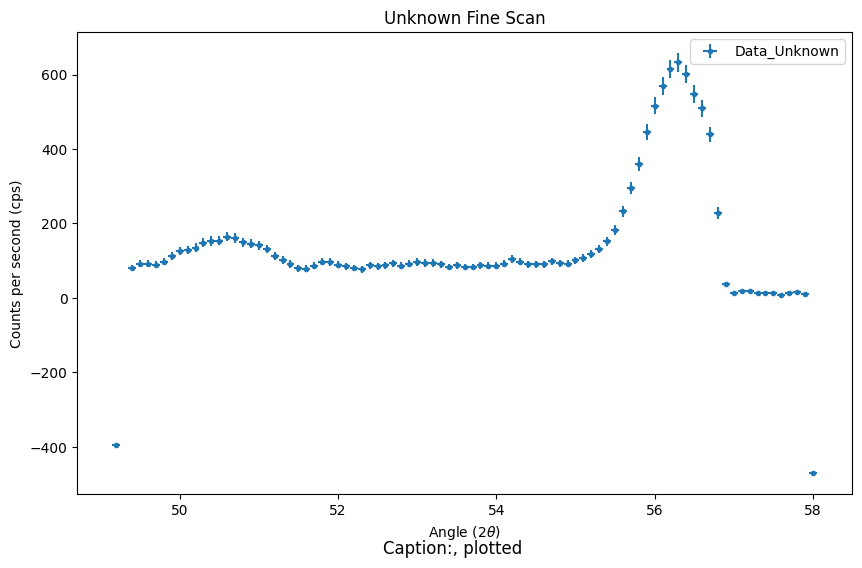

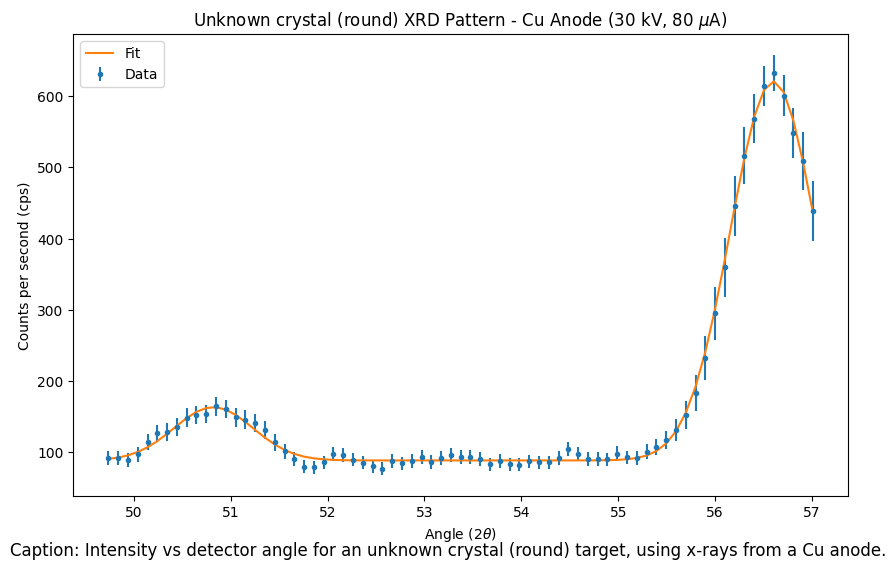

In [9]:
#KEY REMOVE FOR STUDENTS
#Import "UnknownFineScan49-58Dwell20s.txt"
data = genfromtxt("UnknownFineScan49-58Dwell20s.txt", delimiter='	', skip_header=0)
angle = data[:, 0]
cps = 10 * (data[:, 1] - 47)
angle_error = np.array([0.05 for x in angle])
cps_error = np.sqrt(cps)

m = 10.5 / 10.4
b = (m * -35.0) + 35.1
angle_corrected = m * angle + b

angle_corrected_range = angle_corrected[3:76]
cps_range = cps[3:76]
angle_error_range = angle_error[3:76]
cps_error_range = cps_error[3:76]

#Plot the Data
fig0=plt.figure(0,figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(angle, cps, xerr = angle_error, yerr = cps_error, fmt='.', label="Data_Unknown")
plt.legend()
plt.xlabel(r'Angle ($2\theta$)')
plt.ylabel('Counts per second (cps)')
plt.title('Unknown Fine Scan')
plt.figtext(0.5, 0.01, "Caption:, plotted", wrap=True, horizontalalignment='center', fontsize=12)

#Make a Model Function
def Gaussian_Unknown(x, a1, mu1, sigma1, a2, mu2, sigma2, y0):
    g = a1 * np.exp(-0.5 * (x - mu1)**2 / sigma1**2) + a2 * np.exp(-0.5 * (x - mu2)**2 / sigma2**2) + y0
    return g

#Preliminarily Fit the Data
guess_a1 = 100
guess_mu1 = 50.5
guess_sigma1 = 3
guess_a2 = 700
guess_mu2 = 56
guess_sigma2 = 3
guess_y0 = 5



guess=np.array([guess_a1, guess_mu1, guess_sigma1, guess_a2, guess_mu2, guess_sigma2, guess_y0])

# Set bounds to keep amplitudes positive
bounds = ([0, 0, 0, 0, 0, 0, 0], 
          [1000, 1000, 1000, 1000, 1000, 1000, 1000])

uw_fits,uw_covs=curve_fit(Gaussian_Unknown, angle_corrected_range, cps_range, p0=guess, bounds=bounds, maxfev=100000)
uw_sig=np.sqrt(np.diag(uw_covs))

#Calculate dg/dx
a1, mu1, sigma1, a2, mu2, sigma2, y0 = uw_fits
dg_dx = -((angle_corrected_range - mu1) / sigma1**2) * a1 * np.exp(-0.5 * (angle_corrected_range - mu1)**2 / sigma1**2) - ((angle_corrected_range - mu2) / sigma2**2) * a2 * np.exp(-0.5 * (angle_corrected_range - mu2)**2 / sigma2**2)
#Calculate total error
sigmas= np.sqrt(cps_error_range**2 + (dg_dx * angle_error_range)**2)

#Perform weighted fit
fits, covs=curve_fit(Gaussian_Unknown, angle_corrected_range, cps_range, p0=guess, sigma=sigmas, bounds=bounds, maxfev=100000)
stds=np.sqrt(np.diag(covs))


#Calculate reduced chi squared
Red_chi_sq_swing= 1.0/(angle_corrected_range.size-7.0) * np.sum((cps_range - Gaussian_Unknown(angle_corrected_range, *fits))**2/sigmas**2)
print(f'Reduced Chi Squared = {Red_chi_sq_swing:.3f}')
print(f"a1 = {fits[0]:.3f} ± {stds[0]:.3f}")
print(f"mu1 = {fits[1]:.3f} ± {stds[1]:.3f}")
print(f"sigma1 = {fits[2]:.3f} ± {stds[2]:.3f}")
print(f"a2 = {fits[3]:.3f} ± {stds[3]:.3f}")
print(f"mu2 = {fits[4]:.3f} ± {stds[4]:.3f}")
print(f"sigma2 = {fits[5]:.3f} ± {stds[5]:.3f}")
print(f"y0 = {fits[6]:.3f} ± {stds[6]:.3f}")
                 

#Plot the fit with the data!
fit_cps_Unknown = Gaussian_Unknown(angle_corrected_range, *fits)
fig1=plt.figure(1, figsize=(10,6), dpi= 100, facecolor='w', edgecolor='k')#This sets up a figure
plt.errorbar(angle_corrected_range, cps_range, yerr=sigmas, fmt='.', label="Data")
plt.plot(angle_corrected_range, fit_cps_Unknown, '-', label="Fit")
plt.legend()
plt.xlabel(r'Angle ($2\theta$)')
plt.ylabel('Counts per second (cps)')
plt.title(r'Unknown crystal (round) XRD Pattern - Cu Anode (30 kV, 80 $\mu$A)')
plt.figtext(0.5, 0.01, "Caption: Intensity vs detector angle for an unknown crystal (round) target, using x-rays from a Cu anode.", wrap=True, horizontalalignment='center', fontsize=12)





In [14]:
#Constants
n = 2

angle1_radians = fits[1] * (np.pi / 180)
angle1_radians_error = stds[1] * (np.pi / 180)

angle2_radians = fits[4] * (np.pi / 180)
angle2_radians_error = stds[4] * (np.pi / 180)

#Calculate lattice spacing using Bragg's Law
d1 = (n * lambda1) / (2 * np.sin(angle1_radians / 2))
d1_error = np.abs(-(n * lambda1 * np.cos(angle1_radians / 2)) / (4 * (np.sin(angle1_radians / 2))**2)) * angle1_radians_error

d2 = (n * lambda2) / (2 * np.sin(angle2_radians / 2))
d2_error = np.abs(-(n * lambda2 * np.cos(angle2_radians / 2)) / (4 * (np.sin(angle2_radians / 2))**2)) * angle2_radians_error

print(f"Lattice Spacing 1 = {d1:.3e} ± {d1_error:.3e} m")
print(f"Lattice Spacing 2 = {d2:.3e} ± {d2_error:.3e} m")

# Nearest neighbor separation of KBr = 3.298 Angstroms (from READ ME X-Ray 2024-1.pdf)

Lattice Spacing 1 = 3.273e-10 ± 1.226e-13 m
Lattice Spacing 2 = 3.283e-10 ± 6.899e-14 m
